# Lab Day 1 — Notebook — MSSV 2A202602919

Forest CoverType · MLP tự định nghĩa bằng PyTorch · chọn cấu hình **chỉ bằng val**, tập eval chỉ dùng ở Part 4.

**Cách chạy (Colab, GPU T4):** mở notebook từ Google Drive → *Runtime → Run all*.
Kết quả ghi vào thư mục nộp (`submission_2A202602919/`): `results/<exp_id>.json`, `figures/<exp_id>.png`,
`figures/compare_<nhóm>.png`, `experiments.xlsx`, `predictions_eval.csv`, `eval_result.json`.

- `QUICK = True` (ô cấu hình bên dưới): chạy thử nhanh mọi ô (2 epoch, 30 000 mẫu train) để bắt lỗi trong vài phút.
  Kết quả khi đó ghi vào một thư mục tạm, **không** dùng để nộp.
- Mỗi thí nghiệm lưu `results/<exp_id>.json` ngay khi chạy xong. Chạy lại notebook sẽ đọc lại kết quả đã có
  thay vì huấn luyện lại (nếu Colab ngắt giữa chừng thì không mất gì). `FORCE_RERUN = True` để huấn luyện lại từ đầu.

In [1]:
# Colab: mount Google Drive và chuyển vào thư mục code/ của bài nộp (ô này không làm gì khi chạy ngoài Colab)
import os, sys
COLAB_DIR = "/content/drive/MyDrive/K4-Track4-Day1-Neuralnetwork/submission_2A202602919/code"
if "google.colab" in sys.modules:
    from google.colab import drive
    drive.mount("/content/drive")
    os.chdir(COLAB_DIR)
    if COLAB_DIR not in sys.path:
        sys.path.insert(0, COLAB_DIR)
print(os.getcwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/K4-Track4-Day1-Neuralnetwork/submission_2A202602919/code


In [2]:
# ===== Cấu hình đường dẫn và môi trường =====
import os, sys, json, time, math, glob, subprocess
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from IPython.display import display, Image

REPO_ROOT = "../.."     # thư mục gốc repo (chứa data/ và scripts/), tính từ submission_<MSSV>/code/
OUT_DIR   = ".."        # nơi ghi figures/, results/, experiments.xlsx, predictions_eval.csv (= submission_<MSSV>/)

QUICK = False           # True: chạy thử nhanh để bắt lỗi (2 epoch, 30 000 mẫu train), ghi vào thư mục tạm
FORCE_RERUN = False     # True: huấn luyện lại mọi thí nghiệm dù đã có results/<exp_id>.json
if QUICK:
    import tempfile
    OUT_DIR = tempfile.mkdtemp(prefix="lab1_quick_")
RESULTS_DIR, FIG_DIR = f"{OUT_DIR}/results", f"{OUT_DIR}/figures"
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print("torch", torch.__version__, "| device:", device)
if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
print("Ghi kết quả vào:", os.path.abspath(OUT_DIR), "| QUICK =", QUICK)

from data import prepare_data
from model import MLP, EXPECTED_PARAMS, count_params, init_weights, activation_stats
from optimizer import build_optimizer, clip_gradients
from train import DEFAULT_CFG, set_seed, evaluate, predict, run_experiment, final_eval
from plots import plot_run, plot_compare, plot_lr_sensitivity
from results_table import save_result, load_result, load_results, to_row, write_xlsx

torch 2.11.0+cu130 | device: cuda
GPU: Tesla T4
Ghi kết quả vào: /content/drive/MyDrive/K4-Track4-Day1-Neuralnetwork/submission_2A202602919 | QUICK = False


## Part 0 — Dữ liệu
Chia sẵn bằng metadata: chạy `scripts/split_data.py` từ thư mục gốc repo (tạo `data/processed/train.npz`, `eval.npz`).
Sau đó tách validation từ train, chuẩn hoá bằng thống kê của train, đưa lên device.

In [3]:
# Chia train/eval theo metadata (script kiểm tra toàn vẹn rồi ghi data/processed/*.npz)
print(subprocess.run([sys.executable, "scripts/split_data.py"], cwd=REPO_ROOT, check=True,
                     capture_output=True, text=True).stdout)

# Tách val 20% từ train (phân tầng, seed 42), chuẩn hoá bằng thống kê của X_tr, đưa lên device.
# prepare_data tự in kích thước các tập và mốc "luôn đoán lớp đa số" trên val (≈ 0.4876).
data = prepare_data(device, val_fraction=0.2, seed=42, processed_dir=f"{REPO_ROOT}/data/processed")
assert (len(data["y_tr"]), len(data["y_val"]), len(data["y_eval"])) == (371_847, 92_962, 116_203)

# 10 cột số trên X_tr sau chuẩn hoá: mean ≈ 0, std ≈ 1
X_num = data["X_tr"][:, :10]
print("mean 10 cột số:", X_num.mean(0).cpu().numpy().round(4))
print("std  10 cột số:", X_num.std(0).cpu().numpy().round(4))
assert X_num.mean(0).abs().max() < 1e-3 and (X_num.std(0) - 1).abs().max() < 1e-3

# Tỉ lệ lớp (%) ở train / val / eval phải gần như bằng nhau (chia phân tầng)
for name in ["y_tr", "y_val", "y_eval"]:
    ratio = 100 * torch.bincount(data[name], minlength=7).float() / len(data[name])
    print(f"{name:7s}", ratio.cpu().numpy().round(3))

train: X (464809, 54) float32, y (464809,) int64, nhãn 0..6 -> data/processed/train.npz
eval : X (116203, 54) float32, y (116203,) int64, nhãn 0..6 -> data/processed/eval.npz

lớp   train(%)   eval(%)
  0    36.461    36.460
  1    48.760    48.760
  2     6.154     6.154
  3     0.473     0.472
  4     1.634     1.634
  5     2.989     2.989
  6     3.530     3.530

đoán luôn lớp đa số (lớp 1) cho accuracy trên eval = 0.4876

train: 371847 | val: 92962 | eval: 116203
Luôn đoán lớp 1: val acc = 0.4876, val macro-F1 = 0.0936
mean 10 cột số: [ 0.0001 -0.      0.     -0.0003 -0.     -0.      0.     -0.      0.
 -0.    ]
std  10 cột số: [1.0001 1.0001 1.0001 1.     1.     1.     0.9999 1.     0.9999 1.0001]
y_tr    [36.461 48.76   6.154  0.473  1.634  2.989  3.53 ]
y_val   [36.46  48.76   6.154  0.472  1.634  2.989  3.53 ]
y_eval  [36.46  48.76   6.154  0.472  1.634  2.989  3.53 ]


**Nhận xét Part 0:** kích thước 371 847 / 92 962 / 116 203 đúng như GUIDE; tỉ lệ lớp ở train/val/eval gần như trùng nhau
(chia phân tầng). Mean/std của 10 cột số chỉ được tính trên `X_tr` rồi áp nguyên cho val và eval: nếu tính trên val/eval thì
thông tin của dữ liệu dùng để đánh giá rò vào bước tiền xử lý (rò rỉ dữ liệu), làm điểm val/eval lạc quan hơn thực tế.
Lớp 3 chỉ chiếm ~0.47% và lớp 4 ~1.6%: đây sẽ là các lớp khó, nên macro-F1 (mỗi lớp trọng số như nhau) là chỉ số chính.

## Part 1 — Model và kiểm tra "sức khoẻ" ban đầu
Quy định: `M-base` = `54 → 256 → 128 → 7`, **47 879 tham số**, logits `(B, 7)`, không softmax trong model.

MLP(
  (net): Sequential(
    (0): Linear(in_features=54, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.0, inplace=False)
    (6): Linear(in_features=128, out_features=7, bias=True)
  )
)
Số tham số: 47879

Đầu vào   (8, 54)
Linear    (8, 256)
ReLU      (8, 256)
Dropout   (8, 256)
Linear    (8, 128)
ReLU      (8, 128)
Dropout   (8, 128)
Linear    (8, 7)

Loss bước 0 trên val = 2.3776  (ln 7 = 1.9459)
Std sau mỗi Linear (4096 mẫu val): [0.689, 0.654, 0.649]

Quá khớp 20 mẫu: loss đầu = 2.3454, loss cuối = 0.00068, accuracy = 1.00


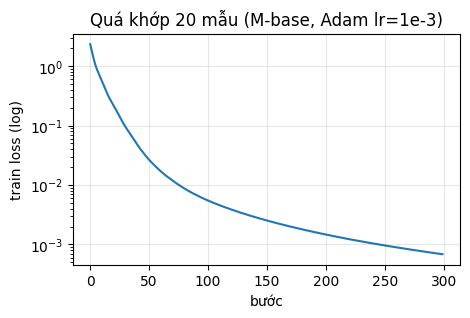


net.0.weight   (256, 54)   grad norm = 0.5823277235031128
net.0.bias     (256,)      grad norm = 0.3833714425563812
net.3.weight   (128, 256)  grad norm = 2.3717989921569824
net.3.bias     (128,)      grad norm = 0.4981728494167328
net.6.weight   (7, 128)    grad norm = 2.0783658027648926
net.6.bias     (7,)        grad norm = 0.6060708165168762


In [4]:
import torch.nn.functional as F

# ---- 1. Tạo model M-base, kiểm tra số tham số
set_seed(42)
model = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
print(model)
n_params = count_params(model)
print("Số tham số:", n_params)
assert n_params == EXPECTED_PARAMS[(256, 128)]

# ---- 2. Lô ngẫu nhiên (8, 54): in shape sau từng lớp
h = torch.randn(8, 54, device=device)
print("\nĐầu vào  ", tuple(h.shape))
for layer in model.net:
    h = layer(h)
    print(f"{type(layer).__name__:9s}", tuple(h.shape))
assert h.shape == (8, 7)

# ---- 3. Loss bước 0 trên toàn bộ val (eval mode, chưa cập nhật lần nào)
model.eval()
with torch.no_grad():
    step0_loss = F.cross_entropy(model(data["X_val"]), data["y_val"]).item()
print(f"\nLoss bước 0 trên val = {step0_loss:.4f}  (ln 7 = {math.log(7):.4f})")
print("Std sau mỗi Linear (4096 mẫu val):", [round(s, 3) for s in activation_stats(model, data["X_val"][:4096])])

# ---- 4. Quá khớp 20 mẫu: tắt dropout, Adam lr 1e-3, 300 bước
set_seed(42)
tiny = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
opt = torch.optim.Adam(tiny.parameters(), lr=1e-3)
xb, yb = data["X_tr"][:20], data["y_tr"][:20]
losses = []
tiny.train()
for step in range(300):
    loss = F.cross_entropy(tiny(xb), yb)
    opt.zero_grad()
    loss.backward()
    opt.step()
    losses.append(loss.item())
tiny.eval()
with torch.no_grad():
    acc20 = (tiny(xb).argmax(1) == yb).float().mean().item()
print(f"\nQuá khớp 20 mẫu: loss đầu = {losses[0]:.4f}, loss cuối = {losses[-1]:.5f}, accuracy = {acc20:.2f}")
assert losses[-1] < 0.01 and acc20 == 1.0

plt.figure(figsize=(5, 3))
plt.semilogy(losses)
plt.xlabel("bước"); plt.ylabel("train loss (log)")
plt.title("Quá khớp 20 mẫu (M-base, Adam lr=1e-3)")
plt.grid(alpha=0.3); plt.show()

# ---- 5. Gradient có chảy tới mọi tham số không (một lô 512 mẫu train)
model.train()
model.zero_grad()
F.cross_entropy(model(data["X_tr"][:512]), data["y_tr"][:512]).backward()
print()
for name, p in model.named_parameters():
    g = p.grad.norm().item() if p.grad is not None else None
    print(f"{name:14s} {str(tuple(p.shape)):11s} grad norm = {g}")
    assert g is not None and g > 0

**Nhận xét Part 1:** loss bước 0 đo được = 2.3776, so với ln 7 = 1.946 cao hơn khoảng 0.43 vì ln 7 chỉ đúng khi 7 logit bằng
nhau (softmax chia đều 1/7), còn ở đây lớp cuối cũng khởi tạo He nên logit có std ≈ 0.65, softmax không đều; mọi mẫu dùng chung
trọng số nên độ lệch này cộng dồn theo cùng một hướng thay vì triệt tiêu. Mức lệch vẫn cùng bậc với ln 7 và các phép thử khác
đều đạt, nên đây không phải lỗi code (Part 3.7 so sánh thêm loss bước 0 của các cách khởi tạo khác); quá khớp 20 mẫu: sau 300
bước Adam (lr = 1e-3, tắt dropout) loss giảm từ 2.3454 xuống 0.00068, accuracy 100%, đường cong giảm đều → model đủ năng lực và
vòng lặp zero_grad → backward → step đúng (không softmax hai lần, không lệch nhãn). Cả 6 tham số đều có grad norm > 0
(0.38–2.37) → gradient chảy tới mọi lớp.

## Part 2 — Pipeline và baseline
`run_experiment(cfg, data)` (trong `train.py`) nhận một dict cấu hình và trả về lịch sử + tóm tắt. Mỗi epoch ghi: train loss
(đo ở chế độ `eval()` trên 50 000 mẫu train cố định), val loss / acc / macro-F1, `grad_norm` trung bình và lớn nhất (đo **trước**
khi clip), thời gian huấn luyện của epoch (có `synchronize`). Ngoài ra: loss bước 0, std kích hoạt bước 0, bộ nhớ GPU cực đại,
cờ `diverged`. Số liệu báo cáo lấy tại **best epoch** = epoch có val loss thấp nhất (như dừng sớm).

**Quy ước công bằng:** cùng phép tách val, 20 epoch, batch 512; mỗi thí nghiệm chỉ đổi **một** yếu tố so với baseline và dùng
seed 1 như `base-s1` (khi đổi nhiều yếu tố hoặc khác seed thì ghi rõ ở cột `notes`). Mọi lựa chọn dựa trên **val macro-F1**.

In [5]:
EPOCHS = 2 if QUICK else 20
DATA = data if not QUICK else {**data, "X_tr": data["X_tr"][:30_000], "y_tr": data["y_tr"][:30_000]}
RESULTS, NOTES = {}, {}      # exp_id -> kết quả (theo thứ tự chạy); exp_id -> ghi chú cho cột notes
BASE = {}                    # thống kê nhiễu của baseline (điền ở Part 2b)


def make_cfg(**changes):
    """Cấu hình = baseline + các thay đổi. Mọi thí nghiệm đều đi qua hàm này."""
    return {**DEFAULT_CFG, "epochs": EPOCHS, **changes}


def _norm_cfg(cfg):
    return json.loads(json.dumps({**DEFAULT_CFG, **cfg, "hidden": list(cfg.get("hidden", DEFAULT_CFG["hidden"]))}))


def run(cfg, notes=""):
    """Chạy một thí nghiệm (hoặc đọc lại results/<exp_id>.json nếu đã chạy với ĐÚNG cấu hình này),
    lưu JSON và ảnh figures/<exp_id>.png."""
    exp_id = cfg["exp_id"]
    path, fig = f"{RESULTS_DIR}/{exp_id}.json", f"{FIG_DIR}/{exp_id}.png"
    res = None
    if os.path.exists(path) and not FORCE_RERUN:
        cached = load_result(path)
        if _norm_cfg(cached["cfg"]) == _norm_cfg(cfg):
            res = cached
            print(f"{exp_id:22s} (đọc lại từ JSON) val_f1={_nan(res['summary']['val_macro_f1']):.4f} "
                  f"best_ep={res['summary']['best_epoch']}")
    if res is None:
        res = run_experiment(cfg, DATA)
        save_result(res, RESULTS_DIR)
        plot_run(res, fig)
    elif not os.path.exists(fig):
        plot_run(res, fig)
    RESULTS[exp_id], NOTES[exp_id] = res, notes
    return res


def _nan(v):
    return float("nan") if v is None else v


def lr_mul(lr, k):
    """lr × k, làm tròn để tránh số kiểu 0.30000000000000004 trong exp_id và bảng."""
    return float(f"{lr * k:.6g}")


def f1_of(exp_id):
    return _nan(RESULTS[exp_id]["summary"]["val_macro_f1"])


def show(ids, extra=()):
    """Bảng tóm tắt (val, tại best epoch) + chênh lệch so với TB baseline và có vượt 2σ không."""
    rows = []
    for i in ids:
        c, s = RESULTS[i]["cfg"], RESULTS[i]["summary"]
        row = {"exp_id": i, "lr": c["lr"], "best_ep": s["best_epoch"], "val_loss": s["best_val_loss"],
               "val_acc": s["val_acc"], "val_f1": s["val_macro_f1"]}
        if BASE and s["val_macro_f1"] is not None:
            row["Δf1 vs base"] = s["val_macro_f1"] - BASE["mean"]
            row["vượt 2σ?"] = "Có" if abs(row["Δf1 vs base"]) > BASE["two_sigma"] else "Không"
        row["t/epoch (s)"] = s["time_per_epoch_s"]
        row["diverged"] = s["diverged"]
        for k in extra:
            row[k] = s.get(k)
        rows.append(row)
    display(pd.DataFrame(rows).set_index("exp_id").round(4))


def show_fig(path, width=1000):
    display(Image(filename=path, width=width))

### 2a. Chọn lr cho baseline (dò bằng val, seed 0)
**Dự đoán trước:** với SGD+momentum 0.9 và batch 512, bước hiệu dụng ≈ lr/(1−0.9) = 10·lr. lr = 0.01 sẽ hội tụ chậm (sau 20 epoch
val macro-F1 còn thấp); lr lớn hơn đi được xa hơn trong cùng số bước nên F1 cao hơn; lr = 0.3 có thể bắt đầu dao động.
Dự đoán lr tốt nhất ≈ 0.1.

**Thiết kế:** dò lr bằng **seed 0**, rồi đo baseline bằng **seed 1–3**: tách việc *chọn* lr khỏi việc *đo* baseline để số
baseline không bị lạc quan do chọn đúng lần chạy may mắn. Các dòng dò lr thuộc nhóm `hparam` (chủ đề lr).

hp-sgdm-lr0.01         (đọc lại từ JSON) val_f1=0.7661 best_ep=20
hp-sgdm-lr0.03         (đọc lại từ JSON) val_f1=0.8216 best_ep=18
hp-sgdm-lr0.1          (đọc lại từ JSON) val_f1=0.8502 best_ep=20
hp-sgdm-lr0.3          (đọc lại từ JSON) val_f1=0.8590 best_ep=19


,lr,best_ep,val_loss,val_acc,val_f1,t/epoch (s),diverged,final_train_loss,final_val_loss
exp_id,,,,,,,,,
hp-sgdm-lr0.01,0.01,20,0.3131,0.8721,0.7661,1.3081,False,0.3002,0.3131
hp-sgdm-lr0.03,0.03,18,0.2688,0.8913,0.8216,1.2854,False,0.2639,0.2814
hp-sgdm-lr0.1,0.10,20,0.2275,0.9092,0.8502,1.2797,False,0.2051,0.2275
hp-sgdm-lr0.3,0.30,19,0.2227,0.9120,0.8590,1.2798,False,0.2027,0.2282


lr chọn cho baseline (val macro-F1 cao nhất): 0.3  (từ hp-sgdm-lr0.3)


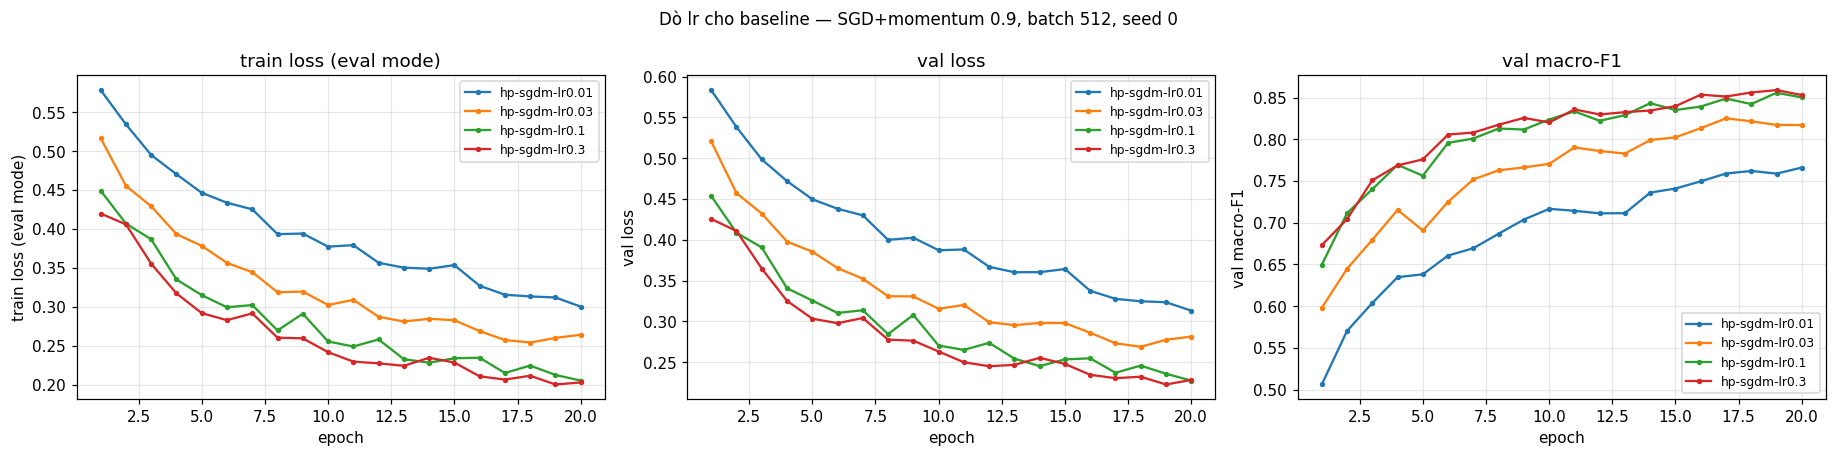

In [6]:
LR_GRID = [0.01, 0.03, 0.1, 0.3]
sweep_ids = []
for lr in LR_GRID:
    cfg = make_cfg(exp_id=f"hp-sgdm-lr{lr:g}", group="hparam", lr=lr, seed=0,
                   description=f"Dò lr cho baseline: SGD+momentum lr={lr:g} (seed 0)")
    run(cfg, notes="dò lr cho baseline bằng seed 0 (tách khỏi seed 1–3 dùng đo nhiễu)")
    sweep_ids.append(cfg["exp_id"])
show(sweep_ids, extra=("final_train_loss", "final_val_loss"))

ok = [i for i in sweep_ids if not RESULTS[i]["summary"]["diverged"]]
best_sweep = max(ok, key=f1_of)
BASE_LR = RESULTS[best_sweep]["cfg"]["lr"]
print(f"lr chọn cho baseline (val macro-F1 cao nhất): {BASE_LR:g}  (từ {best_sweep})")

plot_compare([RESULTS[i] for i in sweep_ids], ["train_loss", "val_loss", "val_macro_f1"],
             f"{FIG_DIR}/compare_lr.png", title="Dò lr cho baseline — SGD+momentum 0.9, batch 512, seed 0")
show_fig(f"{FIG_DIR}/compare_lr.png")

**Đối chiếu sau khi chạy (2a):** F1 tăng đơn điệu theo lr: 0.7661 → 0.8216 → 0.8502 → 0.8590, không lr nào dao động hay NaN. Dự đoán "lr tốt nhất ≈ 0.1" **sai**: lr 0.3 tốt nhất (hơn 0.1 là 0.0088) vì mô hình còn chưa khớp (best epoch 19–20), lr lớn đi được xa hơn trong cùng 14 540 bước. lr 0.3 nằm ở mép lưới; lr ×10 = 3.0 ở 3.5 làm mạng sụp, nên lr tối ưu nằm trong khoảng (0.3, 3). Chọn BASE_LR = 0.3.

### 2b. Baseline với 3 seed và độ nhiễu
**Dự đoán trước:** val loss giảm nhanh vài epoch đầu rồi chậm lại; với 47 879 tham số và 371 847 mẫu, mô hình **chưa quá khớp**
sau 20 epoch (train loss ≈ val loss, có thể val vẫn đang giảm ở epoch cuối). Val accuracy vượt xa mốc 0.4876. Độ lệch giữa
các seed nhỏ (σ của val macro-F1 cỡ vài phần nghìn), nhưng vẫn đủ để các chênh lệch < 2σ không được coi là bằng chứng.

base-s1                (đọc lại từ JSON) val_f1=0.8599 best_ep=20
base-s2                (đọc lại từ JSON) val_f1=0.8653 best_ep=19
base-s3                (đọc lại từ JSON) val_f1=0.8596 best_ep=19
Baseline (3 seed): val macro-F1 = 0.8616 ± 0.0032, val acc = 0.9127 ± 0.0023  (TB ± σ mẫu)
Ngưỡng nhiễu 2σ (val macro-F1) = 0.0064


,lr,best_ep,val_loss,val_acc,val_f1,Δf1 vs base,vượt 2σ?,t/epoch (s),diverged,final_train_loss,final_val_loss,step0_loss
exp_id,,,,,,,,,,,,
base-s1,0.3,20,0.2263,0.9127,0.8599,-0.0017,Không,1.3016,False,0.2014,0.2263,2.2691
base-s2,0.3,19,0.2151,0.9150,0.8653,0.0037,Không,1.4655,False,0.2077,0.2335,1.9782
base-s3,0.3,19,0.2215,0.9104,0.8596,-0.0020,Không,1.3543,False,0.2065,0.2297,1.9005


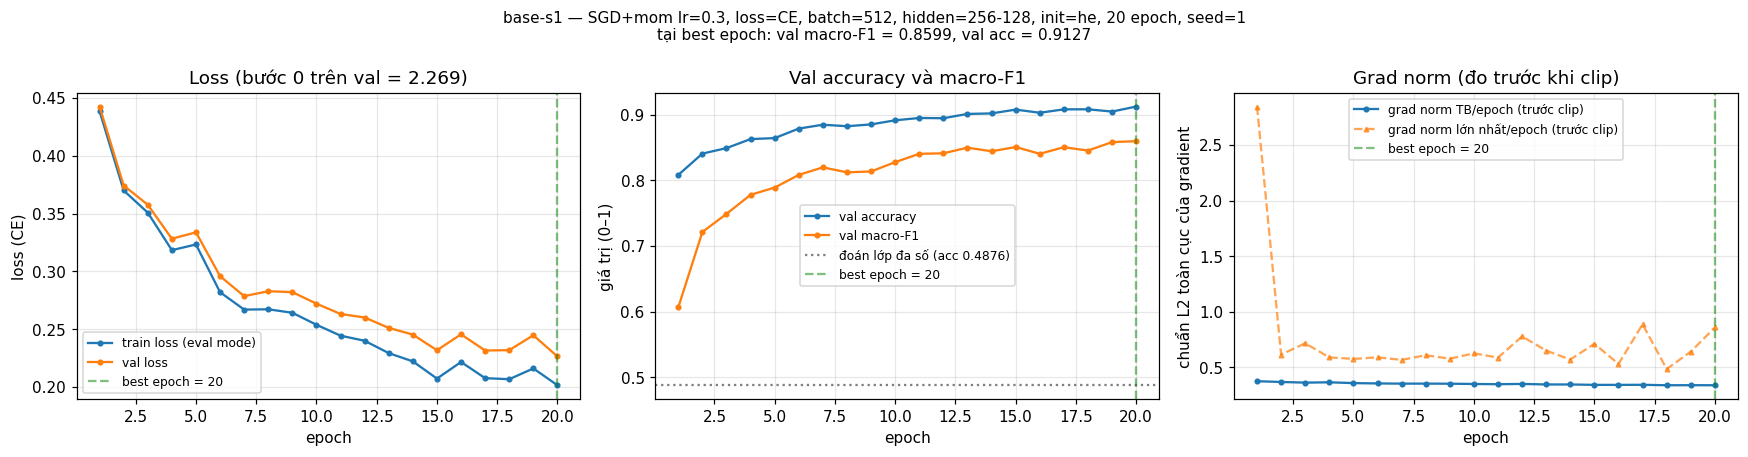

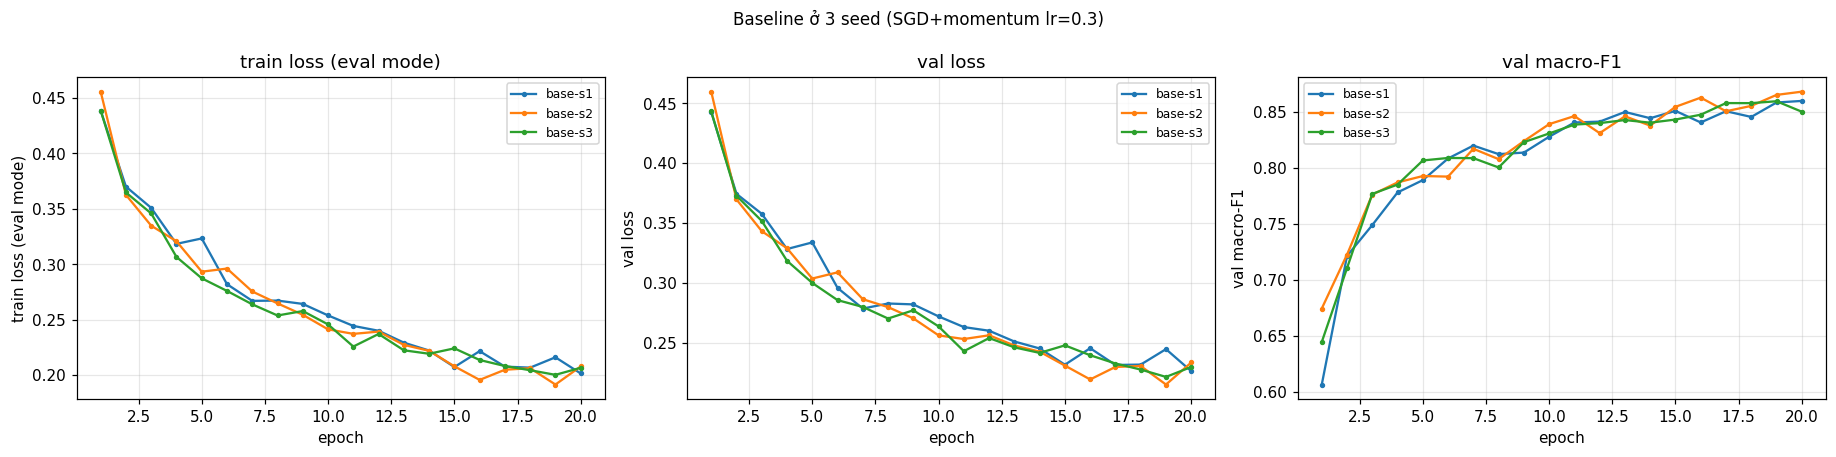

In [7]:
BASE_SEEDS = [1, 2, 3]
base_ids = []
for s in BASE_SEEDS:
    cfg = make_cfg(exp_id=f"base-s{s}", group="baseline", lr=BASE_LR, seed=s,
                   description=f"Baseline M-base, SGD+momentum lr={BASE_LR:g}, seed {s}")
    run(cfg, notes=f"lr={BASE_LR:g} chọn từ {best_sweep} (dò bằng seed 0)")
    base_ids.append(cfg["exp_id"])

f1s = np.array([f1_of(i) for i in base_ids])
accs = np.array([RESULTS[i]["summary"]["val_acc"] for i in base_ids])
BASE.update(mean=f1s.mean(), std=f1s.std(ddof=1), two_sigma=2 * f1s.std(ddof=1))
print(f"Baseline ({len(base_ids)} seed): val macro-F1 = {f1s.mean():.4f} ± {f1s.std(ddof=1):.4f}, "
      f"val acc = {accs.mean():.4f} ± {accs.std(ddof=1):.4f}  (TB ± σ mẫu)")
print(f"Ngưỡng nhiễu 2σ (val macro-F1) = {BASE['two_sigma']:.4f}")
show(base_ids, extra=("final_train_loss", "final_val_loss", "step0_loss"))

plot_compare([RESULTS[i] for i in base_ids], ["train_loss", "val_loss", "val_macro_f1"],
             f"{FIG_DIR}/compare_baseline.png", title=f"Baseline ở 3 seed (SGD+momentum lr={BASE_LR:g})")
show_fig(f"{FIG_DIR}/base-s1.png")
show_fig(f"{FIG_DIR}/compare_baseline.png")

**Nhận xét baseline:** val macro-F1 = 0.8616 ± 0.0032, acc = 0.9127 ± 0.0023 (3 seed) → ngưỡng nhiễu 2σ = 0.0064; vượt xa mốc "đoán lớp đa số" (0.4876). Train/val loss giảm đều và **vẫn đang giảm ở epoch 20** (best epoch 20/19/19), khoảng cách val − train chỉ ≈ 0.025 → mô hình **chưa quá khớp, mà đang chưa khớp** (thiếu bước cập nhật). Grad norm trung bình ổn định ≈ 0.34–0.38, chỉ có gai 2.8 ở epoch 1. Khớp dự đoán, kể cả σ cỡ vài phần nghìn.

## Part 3 — Thí nghiệm
Mỗi chủ đề: **dự đoán trước** → đổi **một** yếu tố so với `base-s1` (seed 1, 20 epoch) → chạy → **đối chiếu** với 2σ của baseline.
Chủ đề đã chạy: optimizer · loss · hparam · dropout · clipping · amp · init (đủ 7/7).

### 3.1 Bộ tối ưu hoá (`optimizer`)
**Dự đoán trước:** Adam/AdamW hội tụ nhanh hơn SGD ở các epoch đầu vì chia bước theo √(trung bình g²) của **từng** tham số:
các trọng số nối với cột one-hot hiếm (Soil_Type) ít khi có gradient nhưng vẫn nhận bước đủ lớn. Khi mỗi bộ được chỉnh lr
công bằng, khoảng cách sau 20 epoch sẽ nhỏ lại. SGD không momentum cần lr lớn hơn ~10 lần SGD+momentum để đi cùng quãng đường.
AdamW (wd = 0.01) ≈ Adam vì suy giảm trọng số nhỏ so với 20 epoch.

**Thiết kế:** mỗi bộ thử 3 lr cách nhau ~3 lần; so ở **lr tốt nhất của từng bộ** (theo val). SGD+momentum dùng lr của baseline
(đã dò ở 2a). Adam/AdamW: betas = (0.9, 0.999), eps = 1e-8.

opt-sgd-lr0.1          (đọc lại từ JSON) val_f1=0.7551 best_ep=18
opt-sgd-lr0.3          (đọc lại từ JSON) val_f1=0.8177 best_ep=18
opt-sgd-lr1            (đọc lại từ JSON) val_f1=0.8314 best_ep=18
opt-adam-lr0.0003      (đọc lại từ JSON) val_f1=0.7878 best_ep=20
opt-adam-lr0.001       (đọc lại từ JSON) val_f1=0.8446 best_ep=18
opt-adam-lr0.003       (đọc lại từ JSON) val_f1=0.8702 best_ep=19
opt-adamw-lr0.0003     (đọc lại từ JSON) val_f1=0.7848 best_ep=20
opt-adamw-lr0.001      (đọc lại từ JSON) val_f1=0.8403 best_ep=18
opt-adamw-lr0.003      (đọc lại từ JSON) val_f1=0.8690 best_ep=18


,lr,best_ep,val_loss,val_acc,val_f1,Δf1 vs base,vượt 2σ?,t/epoch (s),diverged
exp_id,,,,,,,,,
opt-sgd-lr0.1,0.1000,18,0.3481,0.8573,0.7551,-0.1065,Có,1.3049,False
opt-sgd-lr0.3,0.3000,18,0.2807,0.8868,0.8177,-0.0439,Có,1.3377,False
opt-sgd-lr1,1.0000,18,0.2591,0.8964,0.8314,-0.0302,Có,1.3494,False
opt-adam-lr0.0003,0.0003,20,0.3127,0.8729,0.7878,-0.0738,Có,1.5201,False
opt-adam-lr0.001,0.0010,18,0.2443,0.9021,0.8446,-0.0170,Có,1.5316,False
opt-adam-lr0.003,0.0030,19,0.2169,0.9136,0.8702,0.0086,Có,1.5368,False
opt-adamw-lr0.0003,0.0003,20,0.3156,0.8718,0.7848,-0.0767,Có,1.5009,False
opt-adamw-lr0.001,0.0010,18,0.2487,0.9002,0.8403,-0.0213,Có,1.5151,False
opt-adamw-lr0.003,0.0030,18,0.2171,0.9123,0.8690,0.0074,Có,1.5663,False


lr tốt nhất của từng bộ: {'sgd_momentum': 'base-s1', 'sgd': 'opt-sgd-lr1', 'adam': 'opt-adam-lr0.003', 'adamw': 'opt-adamw-lr0.003'}


,lr,best_ep,val_loss,val_acc,val_f1,Δf1 vs base,vượt 2σ?,t/epoch (s),diverged
exp_id,,,,,,,,,
base-s1,0.300,20,0.2263,0.9127,0.8599,-0.0017,Không,1.3016,False
opt-sgd-lr1,1.000,18,0.2591,0.8964,0.8314,-0.0302,Có,1.3494,False
opt-adam-lr0.003,0.003,19,0.2169,0.9136,0.8702,0.0086,Có,1.5368,False
opt-adamw-lr0.003,0.003,18,0.2171,0.9123,0.8690,0.0074,Có,1.5663,False


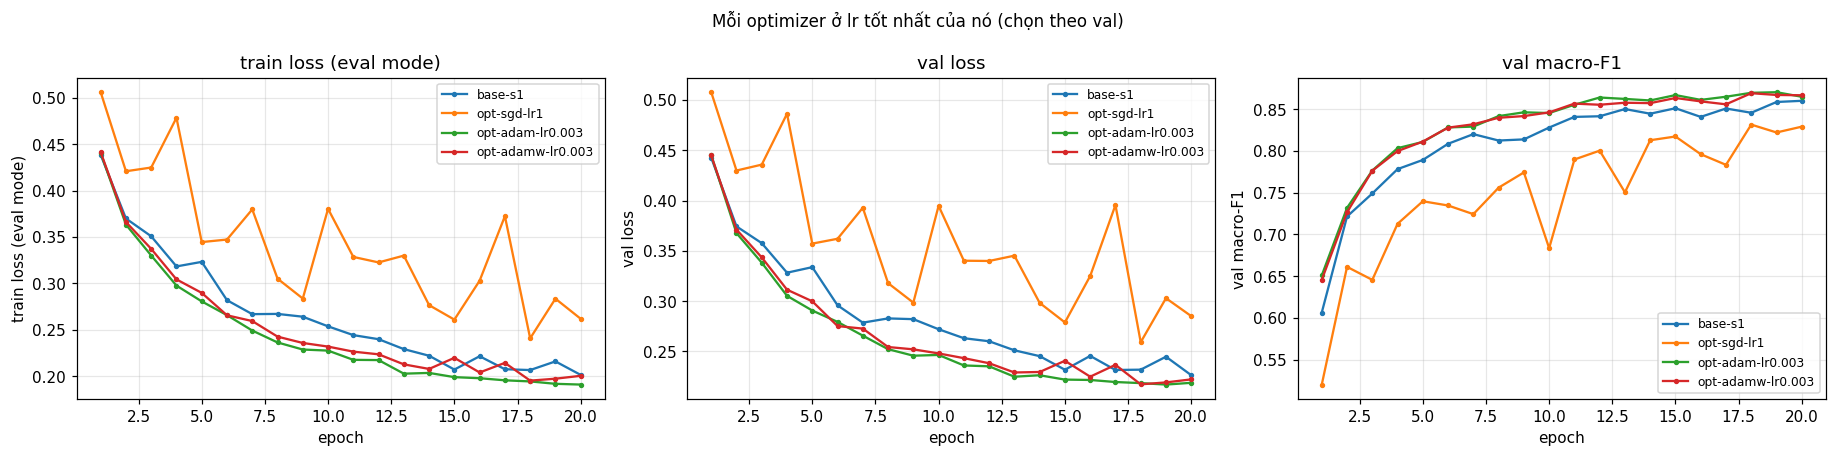

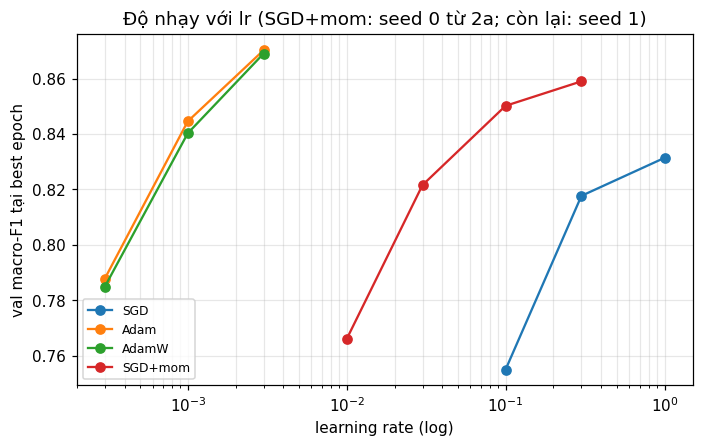

In [8]:
OPT_GRID = {"sgd": [0.1, 0.3, 1.0], "adam": [3e-4, 1e-3, 3e-3], "adamw": [3e-4, 1e-3, 3e-3]}
OPT_LABEL = {"sgd": "SGD (không momentum)", "adam": "Adam", "adamw": "AdamW"}
opt_ids = []
for opt, lrs in OPT_GRID.items():
    for lr in lrs:
        wd = 0.01 if opt == "adamw" else 0.0
        cfg = make_cfg(exp_id=f"opt-{opt}-lr{lr:g}", group="optimizer", optimizer=opt, lr=lr, weight_decay=wd, seed=1,
                       description=f"Đổi optimizer: {OPT_LABEL[opt]} lr={lr:g}" + (f", weight_decay={wd:g}" if wd else ""))
        notes = "momentum=0" if opt == "sgd" else "betas=(0.9,0.999), eps=1e-8" + (", wd tách riêng (AdamW)" if wd else "")
        run(cfg, notes=notes)
        opt_ids.append(cfg["exp_id"])
show(opt_ids + ["base-s1"])

# lr tốt nhất của từng bộ tối ưu (theo val macro-F1)
best_per_opt = {"sgd_momentum": "base-s1"}
for opt in OPT_GRID:
    cand = [i for i in opt_ids if RESULTS[i]["cfg"]["optimizer"] == opt and not RESULTS[i]["summary"]["diverged"]]
    best_per_opt[opt] = max(cand, key=f1_of)
print("lr tốt nhất của từng bộ:", best_per_opt)
show(list(best_per_opt.values()))

plot_compare([RESULTS[i] for i in best_per_opt.values()], ["train_loss", "val_loss", "val_macro_f1"],
             f"{FIG_DIR}/compare_optimizer.png", title="Mỗi optimizer ở lr tốt nhất của nó (chọn theo val)")
plot_lr_sensitivity([RESULTS[i] for i in opt_ids + sweep_ids], f"{FIG_DIR}/compare_optimizer_lr.png",
                    title="Độ nhạy với lr (SGD+mom: seed 0 từ 2a; còn lại: seed 1)")
show_fig(f"{FIG_DIR}/compare_optimizer.png")
show_fig(f"{FIG_DIR}/compare_optimizer_lr.png", width=600)

**Đối chiếu sau khi chạy (3.1):** Adam/AdamW nhanh hơn ở đầu (F1 epoch 1: 0.651 so với 0.606 của base-s1) và tốt nhất ở lr của mình: Adam 0.8702 (+0.0086 so với TB baseline, vừa vượt 2σ, 1 seed → bằng chứng yếu), AdamW 0.8690, SGD+momentum 0.8616, SGD 0.8314 (−0.030). Adam ≈ AdamW (chênh ≤ 0.0043 < 2σ ở cả 3 lr) và SGD cần lr ~10× SGD+momentum (tốt nhất ở lr 1.0): khớp dự đoán. Lưu ý: lr tốt nhất của mọi bộ đều nằm ở **mép lưới** nên "Adam thắng" chỉ đúng trong lưới đã thử.

### 3.2 Hàm mất mát (`loss`): CE vs MSE
**Dự đoán trước:** MSE tính trên logit thô và one-hot (`F.mse_loss`, trung bình trên mọi phần tử B×7, không hệ số 1/2) cho
gradient theo logit = 2(z − t)/7: ngay từ bước đầu, gradient của lớp đúng chỉ ≈ 0.29 so với ≈ 0.86 của CE (p − y), và không
lớn lên khi mô hình dự đoán sai nặng (CE không bão hoà). Dự đoán MSE học chậm hơn → val macro-F1 thấp hơn baseline ở cùng lr,
nhất là ở các lớp hiếm. Vì gradient nhỏ hơn ~3 lần, thử thêm MSE với lr ×3 để so công bằng hơn.
**Lưu ý:** không so giá trị loss CE với MSE (khác thang đo); chỉ so accuracy và macro-F1.

loss-mse-lr0.3         (đọc lại từ JSON) val_f1=0.7735 best_ep=20
loss-mse-lr0.9         (đọc lại từ JSON) val_f1=0.7489 best_ep=19


,lr,best_ep,val_loss,val_acc,val_f1,Δf1 vs base,vượt 2σ?,t/epoch (s),diverged
exp_id,,,,,,,,,
base-s1,0.3,20,0.2263,0.9127,0.8599,-0.0017,Không,1.3016,False
loss-mse-lr0.3,0.3,20,0.0275,0.8812,0.7735,-0.0880,Có,1.3868,False
loss-mse-lr0.9,0.9,19,0.0325,0.8596,0.7489,-0.1127,Có,1.4112,False


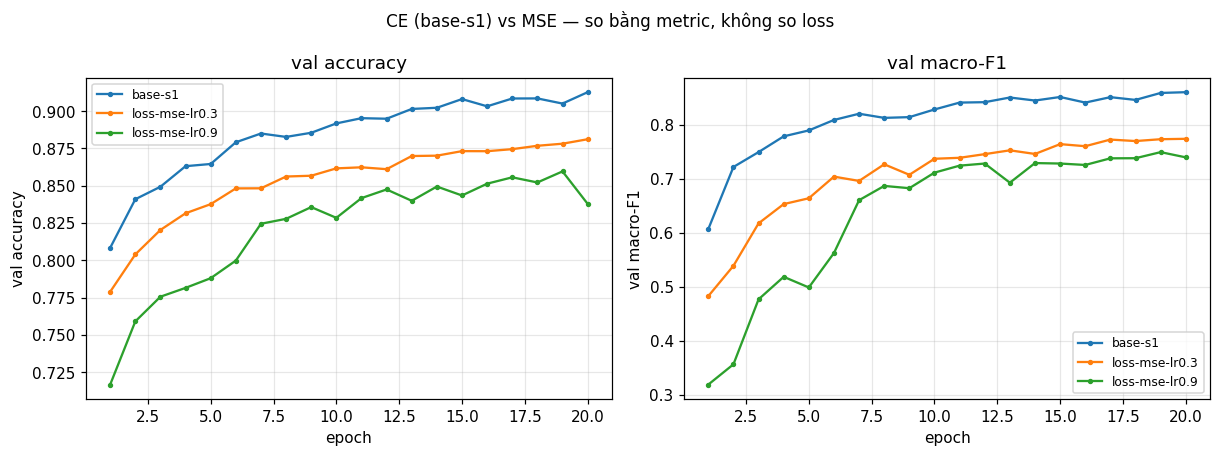

In [9]:
loss_ids = []
for mult in (1, 3):
    lr = lr_mul(BASE_LR, mult)
    cfg = make_cfg(exp_id=f"loss-mse-lr{lr:g}", group="loss", loss="mse", lr=lr, seed=1,
                   description=f"Đổi loss: MSE trên one-hot, lr={lr:g}" + (" (×3 để bù gradient nhỏ hơn)" if mult > 1 else ""))
    run(cfg, notes="MSE = F.mse_loss(logit, one-hot): TB trên B×7 phần tử, không hệ số 1/2; step0_loss là MSE, không so với ln 7")
    loss_ids.append(cfg["exp_id"])
show(["base-s1"] + loss_ids)
plot_compare([RESULTS[i] for i in ["base-s1"] + loss_ids], ["val_acc", "val_macro_f1"],
             f"{FIG_DIR}/compare_loss.png", title="CE (base-s1) vs MSE — so bằng metric, không so loss")
show_fig(f"{FIG_DIR}/compare_loss.png", width=800)

**Đối chiếu sau khi chạy (3.2):** MSE kém CE rõ rệt: F1 0.7735 (lr 0.3) và 0.7489 (lr 0.9) so với 0.8616, vượt xa 2σ — khớp chiều dự đoán. Grad norm trung vị của MSE 0.065 so với 0.347 của CE xác nhận gradient nhỏ hơn ~5×. Nhưng lr ×3 **không** bù được mà còn tệ hơn → nguyên nhân không chỉ là độ lớn gradient: MSE ép mọi logit về đúng 0/1 (kể cả ở mẫu đã đúng) thay vì chỉ tách logit đúng khỏi các logit khác. F1 giảm gần 3 lần accuracy (−0.088 so với −0.032) → lớp hiếm chịu thiệt nhất.

### 3.3 Hyper-parameter (`hparam`): batch size, độ rộng, độ sâu
**Dự đoán trước:**
- Cùng 20 epoch nhưng **batch 128** có 4× số bước cập nhật (2 906 so với 727 bước/epoch) → val F1 cao hơn, nhưng mỗi epoch chậm
  hơn ~3–4 lần (chi phí mỗi bước gần như cố định với mạng nhỏ). **Batch 2048** chỉ có 182 bước/epoch → F1 thấp hơn.
- Quy tắc tăng lr theo lô (lô ×4 thì lr ×4, ở đây không có khởi động) bù lại phần lớn khoảng cách của batch 2048 — nếu lr ×4
  chưa vượt ngưỡng mất ổn định.
- Baseline đang chưa khớp, nên **M-wide** (161 287 tham số) và **M-deep** (55 687) tăng năng lực → val F1 cao hơn; M-wide lợi
  nhiều hơn vì tăng tham số nhiều hơn.

hp-batch128            (đọc lại từ JSON) val_f1=0.7965 best_ep=18
hp-batch2048           (đọc lại từ JSON) val_f1=0.8375 best_ep=18
hp-batch2048-lrx4      (đọc lại từ JSON) val_f1=0.0936 best_ep=11
hp-wide                (đọc lại từ JSON) val_f1=0.8749 best_ep=20
hp-deep                (đọc lại từ JSON) val_f1=0.8434 best_ep=18


,lr,best_ep,val_loss,val_acc,val_f1,Δf1 vs base,vượt 2σ?,t/epoch (s),diverged,steps_per_epoch,n_params,final_train_loss,final_val_loss
exp_id,,,,,,,,,,,,,
base-s1,0.3,20,0.2263,0.9127,0.8599,-0.0017,Không,1.3016,False,727,47879,0.2014,0.2263
hp-batch128,0.3,18,0.3202,0.8798,0.7965,-0.0650,Có,5.4135,False,2906,47879,0.2957,0.3229
hp-batch2048,0.3,18,0.2460,0.9011,0.8375,-0.0241,Có,0.3461,False,182,47879,0.2285,0.2476
hp-batch2048-lrx4,1.2,11,1.2052,0.4876,0.0936,-0.7679,Có,0.3524,False,182,47879,1.2020,1.2053
hp-wide,0.3,20,0.1936,0.9237,0.8749,0.0133,Có,1.3729,False,727,161287,0.1610,0.1936
hp-deep,0.3,18,0.2242,0.9127,0.8434,-0.0182,Có,1.5544,False,727,55687,0.1999,0.2281


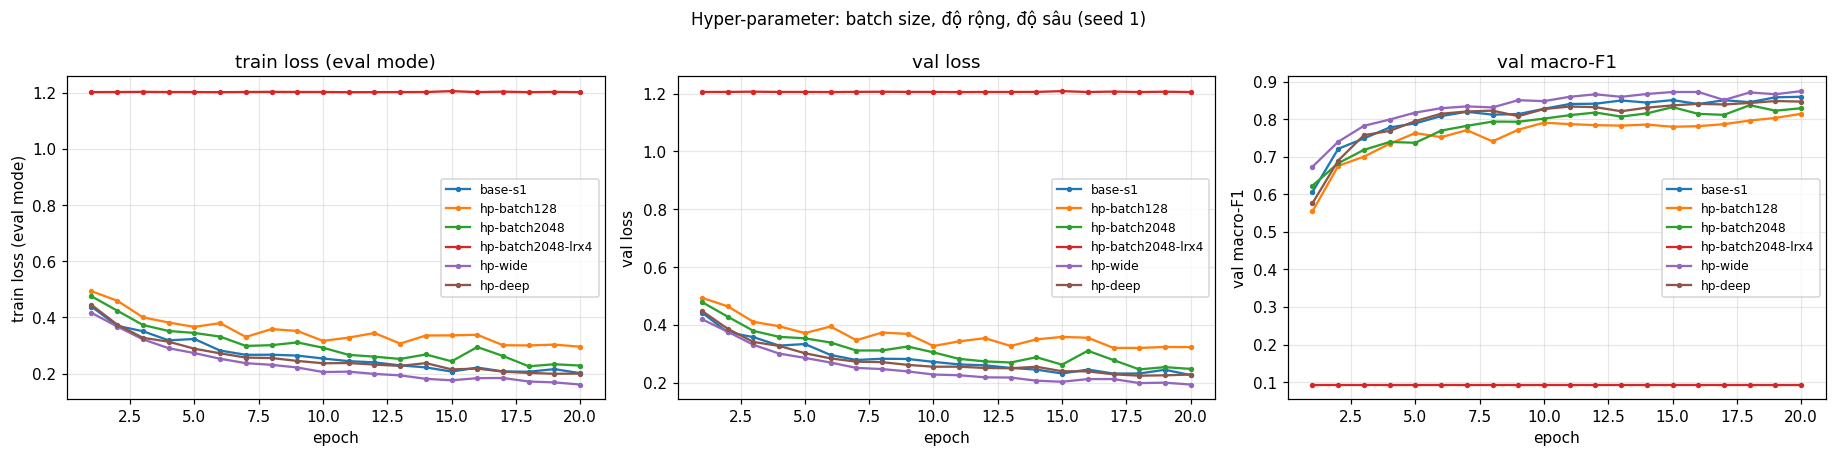

In [10]:
HP_RUNS = [
    dict(exp_id="hp-batch128", batch=128, description="Đổi batch: 128 (4× số bước/epoch), giữ lr"),
    dict(exp_id="hp-batch2048", batch=2048, description="Đổi batch: 2048 (1/4 số bước/epoch), giữ lr"),
    dict(exp_id="hp-batch2048-lrx4", batch=2048, lr=lr_mul(BASE_LR, 4),
         description=f"Batch 2048 + lr ×4 = {lr_mul(BASE_LR, 4):g} (quy tắc tăng lr theo lô, không warmup)"),
    dict(exp_id="hp-wide", hidden=(512, 256), description="Đổi kiến trúc: M-wide 54→512→256→7"),
    dict(exp_id="hp-deep", hidden=(256, 128, 64), description="Đổi kiến trúc: M-deep 54→256→128→64→7"),
]
hp_ids = []
for ch in HP_RUNS:
    cfg = make_cfg(**{"group": "hparam", "lr": BASE_LR, "seed": 1, **ch})
    notes = "đổi 2 yếu tố có chủ đích (batch và lr)" if ch["exp_id"].endswith("lrx4") else ""
    run(cfg, notes=notes)
    hp_ids.append(cfg["exp_id"])
show(["base-s1"] + hp_ids, extra=("steps_per_epoch", "n_params", "final_train_loss", "final_val_loss"))
plot_compare([RESULTS[i] for i in ["base-s1"] + hp_ids], ["train_loss", "val_loss", "val_macro_f1"],
             f"{FIG_DIR}/compare_hparam.png", title="Hyper-parameter: batch size, độ rộng, độ sâu (seed 1)")
show_fig(f"{FIG_DIR}/compare_hparam.png")

**Đối chiếu sau khi chạy (3.3):** M-wide khớp dự đoán (+0.0133, vượt 2σ). Ba điểm **trái dự đoán**: (1) batch 128 tệ hơn nhiều (0.7965) dù có 4× số bước — ở cùng lr 0.3, gradient lô nhỏ nhiễu hơn (grad norm trung vị 0.436 so với 0.347, gai tới 4.7); theo quy tắc tăng lr theo lô thì lô 128 cần lr ≈ 0.075; mỗi epoch chậm 4.3×. (2) batch 2048 + lr ×4 sụp ngay epoch 1 (grad norm max 14.8, sau đó loss đứng ở 1.202 = entropy phân bố lớp) → quy tắc này cần warmup. (3) M-deep có accuracy bằng baseline (0.9127) nhưng macro-F1 thấp hơn 0.018 → kém ở lớp hiếm; chưa giải thích được (1 seed). Batch 2048 giữ lr: −0.024 vì chỉ 182 bước/epoch, nhưng nhanh 3.7×/epoch.

### 3.4 Dropout (`dropout`)
**Dự đoán trước:** dropout là thuốc cho quá khớp, nhưng baseline đang **chưa** quá khớp (khoảng cách val − train loss nhỏ).
Vì vậy dropout chủ yếu làm giảm năng lực hiệu dụng và làm nhiễu gradient → cả train loss lẫn val loss (đo ở `eval()`) đều cao
hơn và val F1 thấp hơn baseline; q càng lớn càng tệ. Khoảng cách val − train sẽ nhỏ lại (hoặc âm).

drop-0.1               (đọc lại từ JSON) val_f1=0.8411 best_ep=20
drop-0.3               (đọc lại từ JSON) val_f1=0.7751 best_ep=20
drop-0.5               (đọc lại từ JSON) val_f1=0.6548 best_ep=20


,lr,best_ep,val_loss,val_acc,val_f1,Δf1 vs base,vượt 2σ?,t/epoch (s),diverged,final_train_loss,final_val_loss
exp_id,,,,,,,,,,,
base-s1,0.3,20,0.2263,0.9127,0.8599,-0.0017,Không,1.3016,False,0.2014,0.2263
drop-0.1,0.3,20,0.2403,0.9014,0.8411,-0.0205,Có,1.4769,False,0.2273,0.2403
drop-0.3,0.3,20,0.3143,0.8704,0.7751,-0.0865,Có,1.4374,False,0.3110,0.3143
drop-0.5,0.3,20,0.4186,0.8247,0.6548,-0.2068,Có,1.4777,False,0.4153,0.4186


Khoảng cách val − train loss ở epoch cuối: {'base-s1': 0.0249, 'drop-0.1': 0.013, 'drop-0.3': 0.0033, 'drop-0.5': 0.0033}


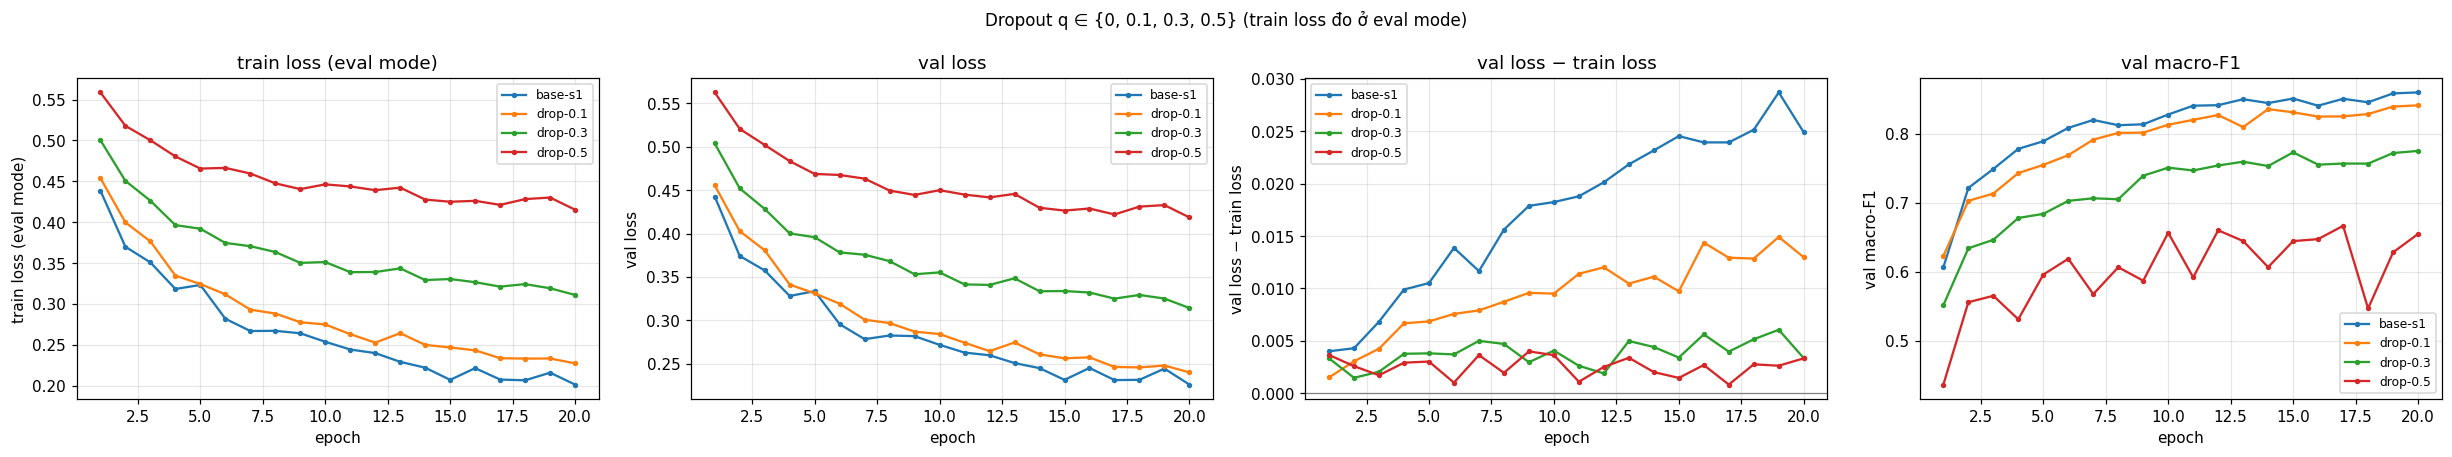

In [11]:
drop_ids = []
for q in (0.1, 0.3, 0.5):
    cfg = make_cfg(exp_id=f"drop-{q:g}", group="dropout", dropout=q, lr=BASE_LR, seed=1,
                   description=f"Thêm dropout q={q:g} sau mỗi ReLU của lớp ẩn")
    run(cfg)
    drop_ids.append(cfg["exp_id"])
gap = lambda i: RESULTS[i]["summary"]["final_val_loss"] - RESULTS[i]["summary"]["final_train_loss"]
show(["base-s1"] + drop_ids, extra=("final_train_loss", "final_val_loss"))
print("Khoảng cách val − train loss ở epoch cuối:", {i: round(gap(i), 4) for i in ["base-s1"] + drop_ids})
plot_compare([RESULTS[i] for i in ["base-s1"] + drop_ids], ["train_loss", "val_loss", "gap", "val_macro_f1"],
             f"{FIG_DIR}/compare_dropout.png", title="Dropout q ∈ {0, 0.1, 0.3, 0.5} (train loss đo ở eval mode)")
show_fig(f"{FIG_DIR}/compare_dropout.png")

**Đối chiếu sau khi chạy (3.4):** khớp dự đoán: F1 giảm đơn điệu 0.8411 / 0.7751 / 0.6548 (q = 0.1 / 0.3 / 0.5), khoảng cách val − train thu hẹp 0.025 → 0.013 → 0.003. Dropout đang chính quy hoá đúng nghĩa, nhưng vì mô hình không quá khớp nên nó chỉ làm giảm năng lực hiệu dụng (train loss đo ở eval mode cũng tăng).

### 3.5 Cắt gradient (`clipping`)
**Thiết kế:** chọn `c` = trung vị của `grad_norm` (từng bước, trước clip) của `base-s1` → clipping thực sự kích hoạt ở khoảng
một nửa số bước. Phép thử phản chứng: tăng lr ×10 so với baseline, chạy **không clip** và **có clip** với cùng `c`.

**Dự đoán trước:** ở lr bình thường, clipping chỉ rút ngắn các bước có gradient lớn mà không đổi hướng → val F1 gần như baseline
(chênh < 2σ), có thể chậm hơn chút. Ở lr ×10 không clip: bước quá lớn (cộng thêm momentum) → loss dao động mạnh hoặc NaN.
Có clip: độ dài mỗi bước bị chặn ở lr·c nên huấn luyện không nổ, dù vẫn có thể kém baseline.

grad norm từng bước của base-s1: trung vị = 0.347, p90 = 0.406 -> chọn c = 0.35; lr cao = 3
clip-c0.35             (đọc lại từ JSON) val_f1=0.8523 best_ep=20
clip-none-highlr       (đọc lại từ JSON) val_f1=0.0936 best_ep=17
clip-c0.35-highlr      (đọc lại từ JSON) val_f1=0.1920 best_ep=10


,lr,best_ep,val_loss,val_acc,val_f1,Δf1 vs base,vượt 2σ?,t/epoch (s),diverged,clip_frac_mean,grad_norm_p50,grad_norm_p90
exp_id,,,,,,,,,,,,
base-s1,0.3,20,0.2263,0.9127,0.8599,-0.0017,Không,1.3016,False,0.0000,0.3475,0.4065
clip-c0.35,0.3,20,0.2275,0.9115,0.8523,-0.0093,Có,1.3512,False,0.6577,0.3669,0.4335
clip-none-highlr,3.0,17,1.2090,0.4876,0.0936,-0.7679,Có,1.3508,False,0.0000,0.0685,0.1529
clip-c0.35-highlr,3.0,10,0.9724,0.5228,0.1920,-0.6696,Có,1.3683,False,0.0308,0.1286,0.2348


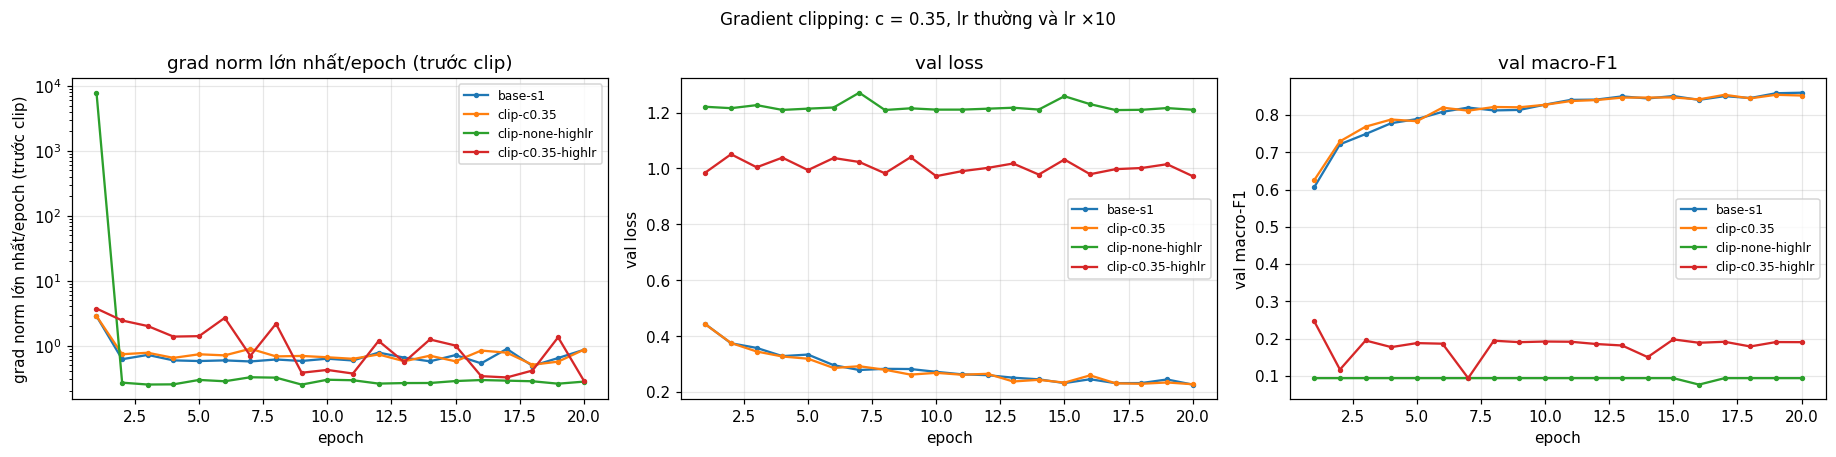

In [12]:
gn50 = RESULTS["base-s1"]["summary"]["grad_norm_p50"]
gn90 = RESULTS["base-s1"]["summary"]["grad_norm_p90"]
CLIP_C = float(f"{gn50:.2g}")
HIGH_LR = lr_mul(BASE_LR, 10)
print(f"grad norm từng bước của base-s1: trung vị = {gn50:.3f}, p90 = {gn90:.3f} -> chọn c = {CLIP_C:g}; lr cao = {HIGH_LR:g}")

CLIP_RUNS = [
    dict(exp_id=f"clip-c{CLIP_C:g}", clip_norm=CLIP_C, lr=BASE_LR,
         description=f"Thêm clipping c={CLIP_C:g} (≈ trung vị grad_norm của base-s1)"),
    dict(exp_id="clip-none-highlr", clip_norm=None, lr=HIGH_LR,
         description=f"lr ×10 = {HIGH_LR:g}, KHÔNG clip (phép thử phản chứng)"),
    dict(exp_id=f"clip-c{CLIP_C:g}-highlr", clip_norm=CLIP_C, lr=HIGH_LR,
         description=f"lr ×10 = {HIGH_LR:g}, clip c={CLIP_C:g}"),
]
clip_ids = []
for ch in CLIP_RUNS:
    cfg = make_cfg(**{"group": "clipping", "seed": 1, **ch})
    run(cfg, notes=f"c chọn từ trung vị grad_norm của base-s1 ({gn50:.3f})" if ch["clip_norm"] else "so sánh với dòng có clip ở cùng lr")
    clip_ids.append(cfg["exp_id"])
show(["base-s1"] + clip_ids, extra=("clip_frac_mean", "grad_norm_p50", "grad_norm_p90"))
plot_compare([RESULTS[i] for i in ["base-s1"] + clip_ids], ["grad_norm_max", "val_loss", "val_macro_f1"],
             f"{FIG_DIR}/compare_clipping.png", title=f"Gradient clipping: c = {CLIP_C:g}, lr thường và lr ×10")
show_fig(f"{FIG_DIR}/compare_clipping.png")

**Đối chiếu sau khi chạy (3.5):** c = 0.35 cắt 66% số bước ở lr 0.3 và làm F1 giảm nhẹ (0.8523, −0.0093, sát 2σ) — khác dự đoán "không đổi": cắt nhiều bước ≈ giảm lr hiệu dụng khi mô hình đang chưa khớp. Ở lr 3.0 không clip: grad norm vọt 7 880 ở epoch 1, mạng sụp về dự đoán tần suất lớp (không NaN, F1 0.0936). Có clip: không có gai (max 3.7), loss ≈ 1.0 thấp hơn mức sụp 1.21, nhưng F1 chỉ 0.19 → clipping chặn được gai gradient nhưng không biến một lr quá lớn thành lr tốt; dự đoán "có clip thì ổn định hơn" chỉ đúng một phần.

### 3.6 Mixed precision (`amp`)
**Thiết kế:** FP16 = `autocast(float16)` + `GradScaler` (`unscale_` trước khi đo/cắt gradient); BF16 = `autocast(bfloat16)`,
không cần GradScaler. Tham số vẫn là FP32. So thời gian huấn luyện mỗi epoch, bộ nhớ GPU cực đại (không tính dữ liệu) và val F1.

**Dự đoán trước:** mạng rất nhỏ (47 879 tham số, batch 512) nên thời gian bị chi phối bởi chi phí gọi kernel/Python chứ không
phải phép nhân ma trận → FP16 **không** nhanh hơn rõ, có thể chậm hơn do thêm phép ép kiểu và GradScaler; bộ nhớ kích hoạt giảm
nhưng vốn đã nhỏ. T4 không có phần cứng BF16 → BF16 chạy giả lập, có thể chậm hơn. Độ chính xác gần như không đổi (chênh < 2σ).
FP16 cần nhân loss với hệ số `s` vì khoảng biểu diễn hẹp (số dương nhỏ nhất bình thường ≈ 6e-5) nên gradient nhỏ bị làm tròn
về 0; BF16 có cùng 8 bit mũ với FP32 (khoảng ≈ 1e-38 … 3e38) nên không bị tràn dưới.

torch.cuda.is_bf16_supported() = True
amp-fp16               (đọc lại từ JSON) val_f1=0.8569 best_ep=20
amp-bf16               (đọc lại từ JSON) val_f1=0.8563 best_ep=18


,lr,best_ep,val_loss,val_acc,val_f1,Δf1 vs base,vượt 2σ?,t/epoch (s),diverged,peak_mem_MB,fp16_skipped_steps
exp_id,,,,,,,,,,,
base-s1,0.3,20,0.2263,0.9127,0.8599,-0.0017,Không,1.3016,False,17.9824,0
amp-fp16,0.3,20,0.2250,0.9105,0.8569,-0.0047,Không,1.8813,False,17.9834,3
amp-bf16,0.3,18,0.2256,0.9108,0.8563,-0.0053,Không,1.6627,False,17.9824,0


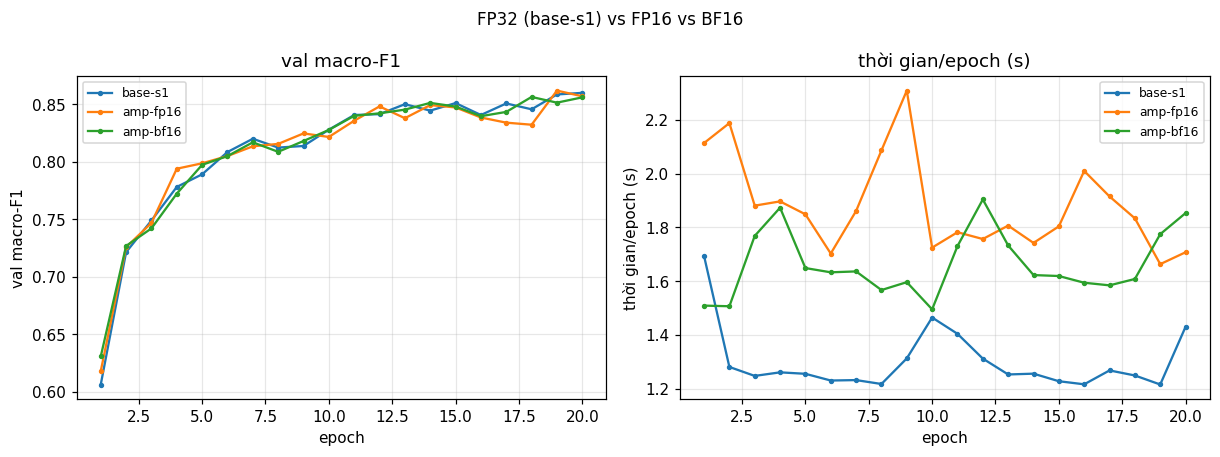

In [13]:
bf16_ok = device == "cuda" and torch.cuda.is_bf16_supported()
print("torch.cuda.is_bf16_supported() =", bf16_ok)
amp_ids = []
for prec in ("fp16", "bf16"):
    cfg = make_cfg(exp_id=f"amp-{prec}", group="amp", precision=prec, lr=BASE_LR, seed=1,
                   description=f"Mixed precision {prec.upper()}" + (" + GradScaler" if prec == "fp16" else " (không GradScaler)"))
    gpu = torch.cuda.get_device_name(0) if device == "cuda" else device
    note = f"GPU {gpu}"
    if prec == "bf16":
        note += f"; is_bf16_supported={bf16_ok}" + ("; T4 (Turing) không có phần cứng BF16 -> chạy giả lập" if "T4" in gpu else "")
    try:
        run(cfg, notes=note)
        amp_ids.append(cfg["exp_id"])
    except Exception as e:
        print(f"{cfg['exp_id']}: không chạy được -> {type(e).__name__}: {e}")
show(["base-s1"] + amp_ids, extra=("peak_mem_MB", "fp16_skipped_steps"))
plot_compare([RESULTS[i] for i in ["base-s1"] + amp_ids], ["val_macro_f1", "epoch_time_s"],
             f"{FIG_DIR}/compare_amp.png", title="FP32 (base-s1) vs FP16 vs BF16")
show_fig(f"{FIG_DIR}/compare_amp.png", width=800)

**Đối chiếu sau khi chạy (3.6):** khớp dự đoán: không nhanh hơn — FP16 1.88 s/epoch (+48%), BF16 1.66 s (+31%) so với 1.27 s của FP32; F1 0.8569 / 0.8563, chênh < 2σ. GradScaler bỏ qua 3 bước đầu (tràn số ở hệ số khởi đầu 2¹⁶ rồi tự giảm). Bộ nhớ cực đại giống hệt nhau (17.98 MB) vì đỉnh rơi vào bước đánh giá FP32 với lô 8 192, nên cách đo này không thấy được phần tiết kiệm bộ nhớ của AMP (hạn chế).

### 3.7 Khởi tạo tham số (`init`)
Bias = 0 ở mọi cách (trừ `default`). `xavier` dùng `xavier_normal_` (Var = 2/(n_vào + n_ra)), `default` là khởi tạo sẵn của
`nn.Linear` (kaiming_uniform với a = √5 ⇒ Var = 1/(3·n_vào), **không** phải He). Baseline dùng He (Var = 2/n_vào).

**Dự đoán trước:**
- `zeros`: mọi nơ-ron trong một lớp giống hệt nhau và ReLU(0) = 0 nên gradient của W1, W2 (và W3) bằng 0 → chỉ bias lớp cuối học
  được → mô hình chỉ học tần suất lớp: val acc ≈ 0.4876, macro-F1 ≈ 0.09; loss bước 0 = ln 7 đúng tuyệt đối.
- `normal(0, 0.01²)`: std kích hoạt co lại theo từng lớp (≈ 0.03 → 0.004 → 0.0005), logit ≈ 0 nên loss bước 0 ≈ ln 7, nhưng
  gradient của các lớp đầu rất nhỏ → khởi động chậm (vài epoch đầu gần như đứng yên), sau đó có thể đuổi kịp một phần.
- `xavier`, `default`: phương sai giảm dần qua mỗi lớp ReLU (vì ReLU bỏ một nửa phương sai), nhưng mạng chỉ 3 lớp nên khác biệt
  với He nhỏ → val F1 gần baseline. Hiện tượng "tắt dần" như biểu đồ 30 lớp trong slide cần mạng sâu hơn nhiều mới thấy rõ.

init-zeros             (đọc lại từ JSON) val_f1=0.0936 best_ep=16
init-normal            (đọc lại từ JSON) val_f1=0.8640 best_ep=19
init-xavier            (đọc lại từ JSON) val_f1=0.8541 best_ep=18
init-default           (đọc lại từ JSON) val_f1=0.8613 best_ep=20


,lr,best_ep,val_loss,val_acc,val_f1,Δf1 vs base,vượt 2σ?,t/epoch (s),diverged,step0_loss
exp_id,,,,,,,,,,
base-s1,0.3,20,0.2263,0.9127,0.8599,-0.0017,Không,1.3016,False,2.2691
init-zeros,0.3,16,1.2053,0.4876,0.0936,-0.7679,Có,1.3503,False,1.9459
init-normal,0.3,19,0.2191,0.9137,0.8640,0.0024,Không,1.3529,False,1.9460
init-xavier,0.3,18,0.2236,0.9117,0.8541,-0.0075,Có,1.3532,False,2.0222
init-default,0.3,20,0.2161,0.9147,0.8613,-0.0003,Không,1.3616,False,1.9830


Std của tiền kích hoạt sau mỗi Linear ở bước 0 (4096 mẫu val) và loss bước 0:


,sau Linear 1,sau Linear 2,logit (Linear 3),step0_loss
base-s1,0.66091,0.64037,0.57730,2.26908
init-zeros,0.00000,0.00000,0.00000,1.94591
init-normal,0.03434,0.00376,0.00027,1.94600
init-xavier,0.27584,0.21822,0.19156,2.02218
init-default,0.27370,0.11298,0.05851,1.98304


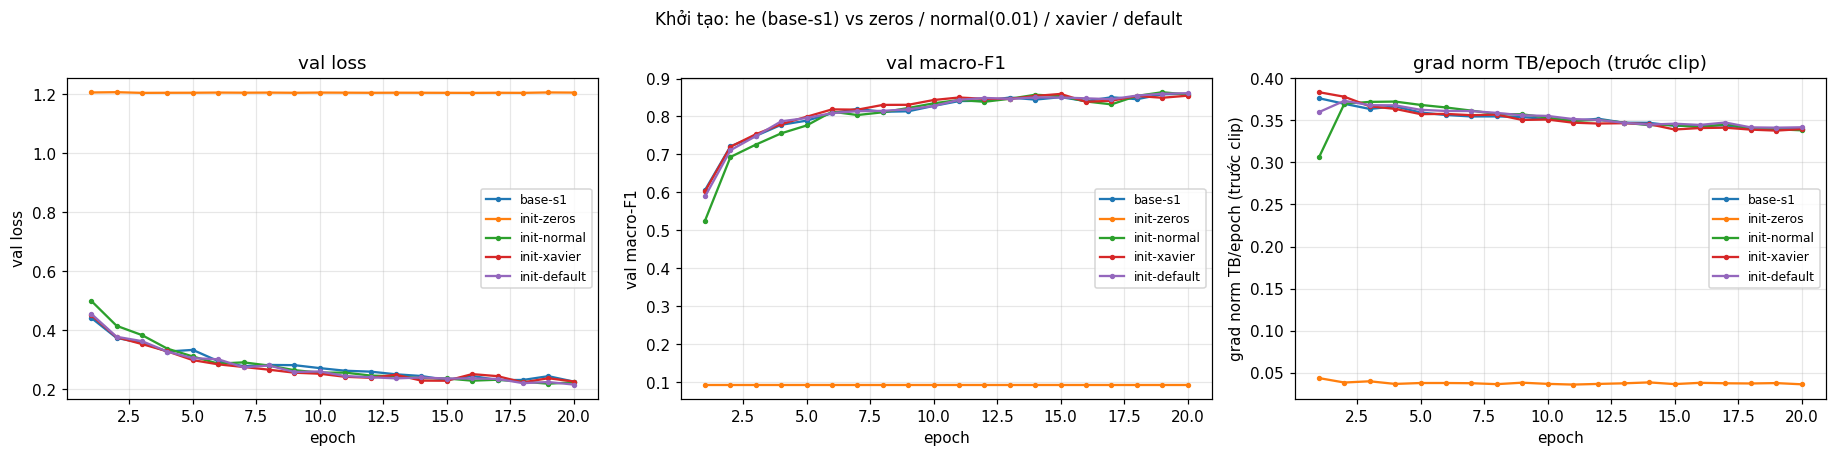

In [14]:
init_ids = []
for init in ("zeros", "normal", "xavier", "default"):
    cfg = make_cfg(exp_id=f"init-{init}", group="init", init=init, lr=BASE_LR, seed=1,
                   description=f"Đổi khởi tạo: {init}")
    run(cfg)
    init_ids.append(cfg["exp_id"])
show(["base-s1"] + init_ids, extra=("step0_loss",))

act = pd.DataFrame({i: RESULTS[i]["summary"]["act_std_step0"] for i in ["base-s1"] + init_ids},
                   index=["sau Linear 1", "sau Linear 2", "logit (Linear 3)"]).T
act["step0_loss"] = [RESULTS[i]["summary"]["step0_loss"] for i in act.index]
print("Std của tiền kích hoạt sau mỗi Linear ở bước 0 (4096 mẫu val) và loss bước 0:")
display(act.round(5))
plot_compare([RESULTS[i] for i in ["base-s1"] + init_ids], ["val_loss", "val_macro_f1", "grad_norm"],
             f"{FIG_DIR}/compare_init.png", title="Khởi tạo: he (base-s1) vs zeros / normal(0.01) / xavier / default")
show_fig(f"{FIG_DIR}/compare_init.png")

**Đối chiếu sau khi chạy (3.7):** zeros đúng như dự đoán (loss bước 0 = 1.9459 = ln 7, sau đó đứng ở 1.205 = entropy phân bố lớp, acc 0.4876). normal(0.01): std 0.034 → 0.0038 → 0.0003 (đúng bậc dự đoán), khởi động chậm (F1 epoch 1: 0.526 so với 0.606) rồi đuổi kịp từ ~epoch 6 (cuối cùng +0.0024 < 2σ). Xavier/default: std co 0.79 / 0.41 lần mỗi lớp như lý thuyết (√(2/3·½) ≈ 0.82 và √(1/6) ≈ 0.41), F1 khác He không quá 2σ (−0.0075 / −0.0003). Loss bước 0 tăng theo std của logit (1.946 → 1.983 → 2.022 → 2.269), xác nhận lời giải thích ở Part 1.

### 3.8 Cấu hình cuối cùng (`final`) — chọn chỉ bằng val
**Thiết kế:** lấy optimizer + lr có val macro-F1 cao nhất ở 3.1 (gồm cả baseline), rồi kết hợp hai điều chỉnh mà baseline cho
thấy có lợi khi mô hình **chưa khớp**: huấn luyện 40 epoch với lr giảm theo cosine (bước nhỏ dần giúp hội tụ sát đáy hơn), và thử
thêm M-wide. Ứng viên có val macro-F1 cao hơn được chạy thêm 2 seed để đo nhiễu. Tập eval **không** tham gia bước nào ở đây.

optimizer tốt nhất theo val: opt-adam-lr0.003 (adam, lr=0.003, wd=0)
final-a-s1             (đọc lại từ JSON) val_f1=0.9042 best_ep=40
final-b-s1             (đọc lại từ JSON) val_f1=0.9243 best_ep=39
Cấu hình cuối cùng (val macro-F1 cao hơn): final-b-s1
final-b-s2             (đọc lại từ JSON) val_f1=0.9226 best_ep=40
final-b-s3             (đọc lại từ JSON) val_f1=0.9284 best_ep=39
Cấu hình cuối (3 seed): val macro-F1 = 0.9251 ± 0.0030  | baseline = 0.8616 ± 0.0032


,lr,best_ep,val_loss,val_acc,val_f1,Δf1 vs base,vượt 2σ?,t/epoch (s),diverged
exp_id,,,,,,,,,
base-s1,0.300,20,0.2263,0.9127,0.8599,-0.0017,Không,1.3016,False
final-a-s1,0.003,40,0.1594,0.9391,0.9042,0.0426,Có,1.5375,False
final-b-s1,0.003,39,0.1244,0.9527,0.9243,0.0627,Có,1.4864,False
final-b-s2,0.003,40,0.1264,0.9530,0.9226,0.0610,Có,1.5316,False
final-b-s3,0.003,39,0.1232,0.9539,0.9284,0.0669,Có,1.5630,False


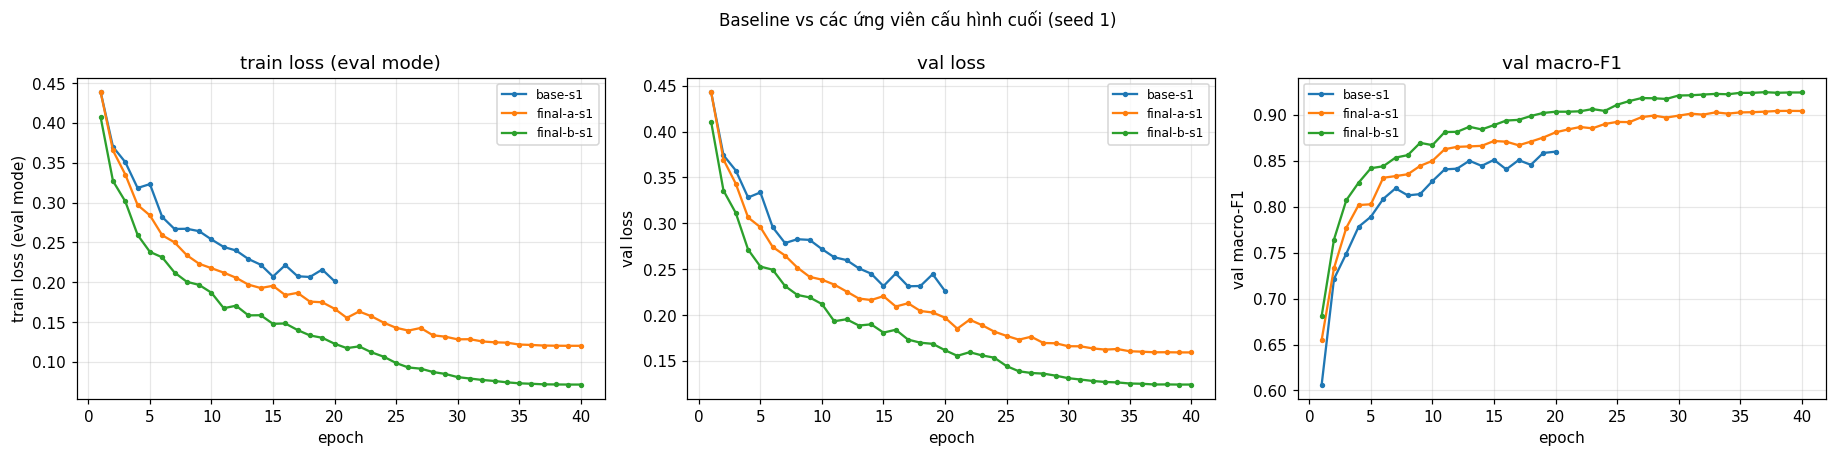

In [15]:
FINAL_EPOCHS = 3 if QUICK else 40
best_opt_id = max(best_per_opt.values(), key=f1_of)
bc = RESULTS[best_opt_id]["cfg"]
print(f"optimizer tốt nhất theo val: {best_opt_id} ({bc['optimizer']}, lr={bc['lr']:g}, wd={bc['weight_decay']:g})")

common = dict(group="final", optimizer=bc["optimizer"], lr=bc["lr"], weight_decay=bc["weight_decay"],
              epochs=FINAL_EPOCHS, scheduler="cosine", seed=1)
final_cands = [
    make_cfg(exp_id="final-a-s1", hidden=(256, 128), **common,
             description=f"Kết hợp: {bc['optimizer']} lr={bc['lr']:g}, {FINAL_EPOCHS} epoch, lr cosine, M-base"),
    make_cfg(exp_id="final-b-s1", hidden=(512, 256), **common,
             description=f"Kết hợp: {bc['optimizer']} lr={bc['lr']:g}, {FINAL_EPOCHS} epoch, lr cosine, M-wide"),
]
for cfg in final_cands:
    run(cfg, notes=f"optimizer/lr lấy từ {best_opt_id} (theo val); đổi nhiều yếu tố có chủ đích")
FINAL_ID = max([c["exp_id"] for c in final_cands], key=f1_of)
print("Cấu hình cuối cùng (val macro-F1 cao hơn):", FINAL_ID)

final_ids = [FINAL_ID]
for s in (2, 3):
    cfg = make_cfg(**{**RESULTS[FINAL_ID]["cfg"], "exp_id": FINAL_ID.replace("-s1", f"-s{s}"), "seed": s})
    run(cfg, notes=f"cùng cấu hình với {FINAL_ID}, khác seed (đo nhiễu)")
    final_ids.append(cfg["exp_id"])
ff1 = np.array([f1_of(i) for i in final_ids])
print(f"Cấu hình cuối ({len(final_ids)} seed): val macro-F1 = {ff1.mean():.4f} ± {ff1.std(ddof=1):.4f}  | "
      f"baseline = {BASE['mean']:.4f} ± {BASE['std']:.4f}")
show(["base-s1"] + [c["exp_id"] for c in final_cands] + final_ids[1:])
plot_compare([RESULTS[i] for i in ["base-s1", "final-a-s1", "final-b-s1"]], ["train_loss", "val_loss", "val_macro_f1"],
             f"{FIG_DIR}/compare_final.png", title="Baseline vs các ứng viên cấu hình cuối (seed 1)")
show_fig(f"{FIG_DIR}/compare_final.png")

**Đối chiếu sau khi chạy (3.8):** chọn theo val: Adam lr 3e-3 là bộ tối ưu tốt nhất; final-a (M-base) 0.9042, final-b (M-wide) 0.9243 → chọn final-b. Ba seed: 0.9251 ± 0.0030, hơn baseline 0.0635 (≫ 2σ). Cấu hình đổi nhiều yếu tố: so với `opt-adam-lr0.003` (20 epoch), 40 epoch + cosine thêm +0.034, M-wide thêm +0.020. Khoảng cách val − train của final-b là 0.053 (lớn hơn baseline) → bắt đầu quá khớp nhẹ, nhưng val loss vẫn thấp nhất ở epoch 39–40.

## Part 4 — Đánh giá cuối trên eval, bảng và nộp bài
Cấu hình đã chốt ở 3.8 bằng val. Ở đây mới dùng eval, **một lần** cho baseline (`base-s1`) và **một lần** cho cấu hình cuối
(seed 1): nạp trọng số ở best epoch → dự đoán toàn bộ eval ở chế độ `eval()` → `scripts/evaluate.py` (đúng script chấm điểm).
Không chỉnh lại gì sau khi thấy điểm eval. (Kết quả đọc lại từ JSON không có trọng số, nên hai mô hình này được huấn luyện lại
với đúng cấu hình và seed trước khi dự đoán.)

In [16]:
def ensure_state(exp_id):
    """Trả về kết quả có best_state; nếu kết quả được đọc từ JSON thì huấn luyện lại đúng cfg đó (cùng seed)."""
    r = RESULTS[exp_id]
    if r.get("best_state") is None:
        print(f"{exp_id}: huấn luyện lại để có trọng số best epoch")
        r = run_experiment(r["cfg"], DATA)
        save_result(r, RESULTS_DIR)
        plot_run(r, f"{FIG_DIR}/{exp_id}.png")
        RESULTS[exp_id] = r
    return r

EVAL_BASE_DIR = f"{RESULTS_DIR}/eval"       # thư mục con: load_results không đọc nhầm vào bảng
os.makedirs(EVAL_BASE_DIR, exist_ok=True)

print("===== Baseline (base-s1) =====")
r_base = ensure_state("base-s1")
eval_base = final_eval(r_base["cfg"], r_base, data, f"{EVAL_BASE_DIR}/base-s1_predictions_eval.csv",
                       repo_root=REPO_ROOT, out_json=f"{EVAL_BASE_DIR}/base-s1_eval_result.json")

print(f"===== Cấu hình cuối cùng ({FINAL_ID}) =====")
r_final = ensure_state(FINAL_ID)
eval_final = final_eval(r_final["cfg"], r_final, data, f"{OUT_DIR}/predictions_eval.csv",
                        repo_root=REPO_ROOT, out_json=f"{OUT_DIR}/eval_result.json")

EVAL_SCORES = {"base-s1": eval_base, FINAL_ID: eval_final}
summary_eval = pd.DataFrame({
    i: {"val_acc": RESULTS[i]["summary"]["val_acc"], "val_macro_f1": RESULTS[i]["summary"]["val_macro_f1"],
        "eval_acc": e["accuracy"], "eval_macro_f1": e["macro_f1"]}
    for i, e in EVAL_SCORES.items()}).T
summary_eval["eval − val (F1)"] = summary_eval["eval_macro_f1"] - summary_eval["val_macro_f1"]
display(summary_eval.round(4))
print(f"Cải thiện eval macro-F1 so với baseline: {eval_final['macro_f1'] - eval_base['macro_f1']:+.4f} "
      f"(ngưỡng nhiễu 2σ trên val = {BASE['two_sigma']:.4f})")

===== Baseline (base-s1) =====
base-s1: huấn luyện lại để có trọng số best epoch
base-s1                val_f1=0.8599 val_acc=0.9127 best_ep=20 step0=2.269 t/ep=1.27s
n_eval = 116203
accuracy = 0.9108
macro_f1 = 0.8616   <- chỉ số chính

lớp  support  precision  recall    f1
  0    42368     0.9209  0.8947  0.9076
  1    56661     0.9170  0.9328  0.9248
  2     7151     0.8873  0.9153  0.9011
  3      549     0.9052  0.6958  0.7868
  4     1899     0.7266  0.8173  0.7693
  5     3473     0.8405  0.7907  0.8148
  6     4102     0.9159  0.9376  0.9266

ma trận nhầm lẫn (hàng = thật, cột = dự đoán):
       0      1     2    3     4     5     6
0  37907   4040     5    0    88     6   322
1   3022  52855   185    0   454   114    31
2      0    187  6545   24    40   355     0
3      0      3   130  382     0    34     0
4     18    289    28    0  1552    12     0
5     13    213   483   16     2  2746     0
6    203     53     0    0     0     0  3846

đã ghi /content/drive/MyDrive/K4-Tr

,val_acc,val_macro_f1,eval_acc,eval_macro_f1,eval − val (F1)
base-s1,0.9127,0.8599,0.9108,0.8616,0.0017
final-b-s1,0.9527,0.9243,0.9530,0.9277,0.0034


Cải thiện eval macro-F1 so với baseline: +0.0661 (ngưỡng nhiễu 2σ trên val = 0.0064)


,support,precision,recall,f1,số mẫu train,% train
cls,,,,,,
0,42368,0.9545,0.9465,0.9505,135578,36.4607
1,56661,0.9558,0.9640,0.9599,181312,48.7598
2,7151,0.9525,0.9508,0.9516,22882,6.1536
3,549,0.8879,0.8652,0.8764,1759,0.4730
4,1899,0.8952,0.8636,0.8791,6075,1.6337
5,3473,0.9172,0.9122,0.9147,11115,2.9891
6,4102,0.9638,0.9595,0.9616,13126,3.5299


,đoán 0,đoán 1,đoán 2,đoán 3,đoán 4,đoán 5,đoán 6
thật 0,40102,2108,1,0,24,2,131
thật 1,1737,54620,76,0,151,60,17
thật 2,1,107,6799,38,12,194,0
thật 3,0,0,55,475,0,19,0
thật 4,34,201,13,0,1640,11,0
thật 5,4,81,194,22,4,3168,0
thật 6,136,29,0,0,1,0,3936


Lớp khó nhất: 3 (F1 = 0.8764, recall = 0.8652); 10.0% mẫu lớp 3 bị đoán thành lớp 2
  lớp 0: recall  94.7% | nhầm nhiều nhất sang lớp 1 (5.0%)
  lớp 1: recall  96.4% | nhầm nhiều nhất sang lớp 0 (3.1%)
  lớp 2: recall  95.1% | nhầm nhiều nhất sang lớp 5 (2.7%)
  lớp 3: recall  86.5% | nhầm nhiều nhất sang lớp 2 (10.0%)
  lớp 4: recall  86.4% | nhầm nhiều nhất sang lớp 1 (10.6%)
  lớp 5: recall  91.2% | nhầm nhiều nhất sang lớp 2 (5.6%)
  lớp 6: recall  96.0% | nhầm nhiều nhất sang lớp 0 (3.3%)

Độ cao (m) theo lớp trên tập train:


,count,mean,std,25%,75%
lớp,,,,,
0,169472.0,3129.0,158.0,3034.0,3236.0
1,226640.0,2921.0,186.0,2794.0,3042.0
2,28603.0,2394.0,196.0,2261.0,2547.0
3,2198.0,2224.0,102.0,2143.0,2304.0
4,7594.0,2788.0,97.0,2732.0,2858.0
5,13894.0,2419.0,189.0,2319.0,2545.0
6,16408.0,3362.0,107.0,3300.0,3409.0


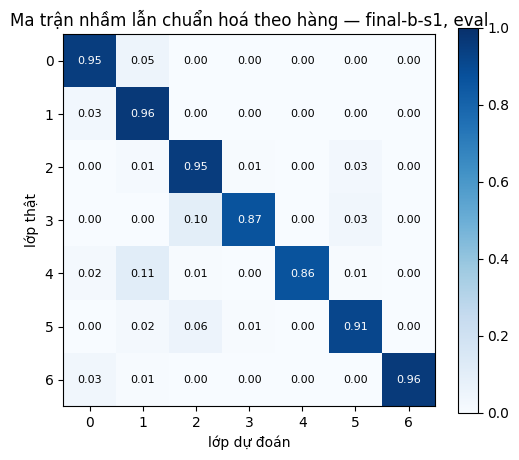

In [17]:
# Phân tích lỗi theo lớp (cấu hình cuối, trên eval) — số lấy từ eval_result.json do evaluate.py tạo
pc = pd.DataFrame(eval_final["per_class"]).set_index("cls")
train_count = np.bincount(data["y_tr"].cpu().numpy(), minlength=7)
pc["số mẫu train"] = train_count
pc["% train"] = 100 * train_count / train_count.sum()
display(pc.round(4))

cm = np.array(eval_final["confusion_matrix"])
display(pd.DataFrame(cm, index=[f"thật {c}" for c in range(7)], columns=[f"đoán {c}" for c in range(7)]))
cm_row = cm / cm.sum(1, keepdims=True)          # chuẩn hoá theo hàng = tỉ lệ của mỗi lớp thật

hardest = int(pc["f1"].idxmin())
off = cm_row[hardest].copy(); off[hardest] = 0
confused = int(off.argmax())
print(f"Lớp khó nhất: {hardest} (F1 = {pc.loc[hardest, 'f1']:.4f}, recall = {pc.loc[hardest, 'recall']:.4f}); "
      f"{100 * off[confused]:.1f}% mẫu lớp {hardest} bị đoán thành lớp {confused}")
for c in range(7):
    o = cm_row[c].copy(); o[c] = 0
    print(f"  lớp {c}: recall {100 * cm_row[c, c]:5.1f}% | nhầm nhiều nhất sang lớp {int(o.argmax())} ({100 * o.max():.1f}%)")

# Đặc trưng: độ cao (Elevation, cột 0, đơn vị mét) theo lớp — tính trên TRAIN (dữ liệu gốc chưa chuẩn hoá)
raw = np.load(f"{REPO_ROOT}/data/processed/train.npz")
elev = pd.DataFrame({"Elevation": raw["X"][:, 0], "lớp": raw["y"]}).groupby("lớp")["Elevation"].describe()
print("\nĐộ cao (m) theo lớp trên tập train:")
display(elev[["count", "mean", "std", "25%", "75%"]].round(0))

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm_row, cmap="Blues", vmin=0, vmax=1)
for a in range(7):
    for b in range(7):
        ax.text(b, a, f"{cm_row[a, b]:.2f}", ha="center", va="center", fontsize=8,
                color="white" if cm_row[a, b] > 0.5 else "black")
ax.set(xlabel="lớp dự đoán", ylabel="lớp thật", xticks=range(7), yticks=range(7),
       title=f"Ma trận nhầm lẫn chuẩn hoá theo hàng — {FINAL_ID}, eval")
fig.colorbar(im); plt.show()

**Phân tích lỗi:** lớp khó nhất là **lớp 3** (Cottonwood/Willow, F1 0.8764, recall 0.8652): 10.0% mẫu bị đoán thành lớp 2 và 3.5% thành lớp 5. Lớp 4 (Aspen, F1 0.8791) có 10.6% mẫu bị đoán thành lớp 1. Lý do theo dữ liệu: lớp 3 chỉ chiếm 0.47% tập train (2 198 mẫu), và độ cao 2 224 ± 102 m của nó trùng khoảng với lớp 2 (2 394 ± 196 m) và lớp 5 (2 419 ± 189 m); lớp 4 (2 788 ± 97 m) nằm trong khoảng của lớp 1 (2 921 ± 186 m). So với baseline, F1 lớp 3 tăng 0.787 → 0.876, lớp 4 0.769 → 0.879. Hướng cải thiện: trọng số lớp trong CE hoặc lấy mẫu dư lớp hiếm, chọn bằng val macro-F1.

In [18]:
# Bảng experiments.xlsx: mỗi thí nghiệm một dòng (thứ tự chạy), eval chỉ cho baseline và cấu hình cuối
def auto_notes(r):
    c, s = r["cfg"], r["summary"]
    parts = []
    if c["clip_norm"] is not None:
        parts.append(f"clip kích hoạt ở {100 * s['clip_frac_mean']:.0f}% số bước")
    if c["group"] == "init" or c["exp_id"] == "base-s1":
        parts.append("std sau mỗi Linear ở bước 0: " + ", ".join(f"{x:.3g}" for x in s["act_std_step0"]))
    if c["precision"] == "fp16":
        parts.append(f"GradScaler bỏ qua {s['fp16_skipped_steps']} bước")
    if c["batch"] != 512:
        parts.append(f"{s['steps_per_epoch']} bước/epoch (baseline 727)")
    if c.get("scheduler"):
        parts.append(f"lr giảm theo {c['scheduler']} về 0")
    if s["diverged"]:
        parts.append("loss thành NaN/inf -> dừng sớm")
    elif s["final_train_loss"] is not None and abs(s["final_train_loss"] - 1.205) < 0.02:
        parts.append("không NaN nhưng sụp về dự đoán tần suất lớp (train loss ≈ 1.205 = entropy phân bố lớp)")
    return "; ".join(parts)

SUMMARY_NOTES = {   # nhận xét ngắn cho sheet Summary
    'baseline': '3 seed, lr 0.3: val F1 0.8616 ± 0.0032 → 2σ = 0.0064; chưa quá khớp (val còn giảm ở epoch 20).',
    'loss': 'MSE kém CE rõ (F1 0.774 / 0.749); gradient nhỏ ~5×; lr ×3 không bù được.',
    'optimizer': 'Ở lr tốt nhất: Adam 0.870 ≈ AdamW 0.869 > SGD+mom 0.862 > SGD 0.831; Adam hơn SGD+mom sát 2σ (1 seed); lr tốt nhất ở mép lưới.',
    'hparam': 'lr 0.3 tốt nhất trong lưới; M-wide +0.013 (>2σ); batch 128 cùng lr tệ hơn (nhiễu); batch 2048 + lr ×4 không warmup sụp; M-deep −0.018 (chưa rõ).',
    'dropout': 'F1 giảm đơn điệu theo q; gap val−train thu hẹp 0.025 → 0.003; mô hình chưa quá khớp nên dropout không giúp.',
    'clipping': 'c = 0.35 (trung vị grad norm) cắt 66% bước, −0.009; lr ×10: không clip sụp (grad 7 880), có clip không nổ nhưng F1 0.19.',
    'amp': 'FP16 / BF16 chậm hơn 48% / 31%, F1 không đổi (< 2σ); mạng nhỏ nên chi phí kernel chiếm ưu thế; T4 không có BF16 phần cứng.',
    'init': 'zeros sụp về tần suất lớp; normal(0.01) khởi động chậm rồi đuổi kịp; xavier/default ≈ He (≤ 2σ) vì mạng chỉ 3 lớp.',
    'final': 'Adam 3e-3 + 40 epoch + cosine + M-wide: val F1 0.9251 ± 0.0030 (3 seed); eval F1 0.9277 so với baseline 0.8616.',
}
rows = [to_row(r, EVAL_SCORES.get(i), notes="; ".join(x for x in (NOTES.get(i, ""), auto_notes(r)) if x))
        for i, r in RESULTS.items()]
write_xlsx(rows, f"{REPO_ROOT}/templates/experiment_table_template.xlsx", f"{OUT_DIR}/experiments.xlsx",
           seeds=base_ids, summary_notes=SUMMARY_NOTES)
print(f"Đã ghi {len(rows)} dòng vào {OUT_DIR}/experiments.xlsx")
display(pd.DataFrame(rows).set_index("exp_id")[["group", "optimizer", "lr", "batch", "hidden", "val_acc", "val_macro_f1",
                                                 "eval_acc", "eval_macro_f1", "diverged"]])

Đã ghi 39 dòng vào ../experiments.xlsx


,group,optimizer,lr,batch,hidden,val_acc,val_macro_f1,eval_acc,eval_macro_f1,diverged
exp_id,,,,,,,,,,
hp-sgdm-lr0.01,hparam,SGD+momentum,0.0100,512,256-128,0.872120,0.766076,NaN,NaN,N
hp-sgdm-lr0.03,hparam,SGD+momentum,0.0300,512,256-128,0.891289,0.821586,NaN,NaN,N
hp-sgdm-lr0.1,hparam,SGD+momentum,0.1000,512,256-128,0.909156,0.850161,NaN,NaN,N
hp-sgdm-lr0.3,hparam,SGD+momentum,0.3000,512,256-128,0.912029,0.858979,NaN,NaN,N
base-s1,baseline,SGD+momentum,0.3000,512,256-128,0.912674,0.859885,0.910760,0.861585,N
base-s2,baseline,SGD+momentum,0.3000,512,256-128,0.915041,0.865273,NaN,NaN,N
base-s3,baseline,SGD+momentum,0.3000,512,256-128,0.910447,0.859595,NaN,NaN,N
opt-sgd-lr0.1,optimizer,SGD,0.1000,512,256-128,0.857254,0.755086,NaN,NaN,N
opt-sgd-lr0.3,optimizer,SGD,0.3000,512,256-128,0.886760,0.817700,NaN,NaN,N


In [19]:
# Kiểm tra trước khi nộp
exp_figs = sorted(p[:-4] for p in os.listdir(FIG_DIR) if p.endswith(".png") and not p.startswith("compare_"))
cmp_figs = sorted(p for p in os.listdir(FIG_DIR) if p.startswith("compare_"))
ids = sorted(RESULTS)
print(f"{len(ids)} dòng trong bảng | {len(exp_figs)} ảnh thí nghiệm | {len(cmp_figs)} ảnh compare: {cmp_figs}")
print("Ảnh khớp đúng exp_id:", "OK" if exp_figs == ids else
      f"KHÔNG — thiếu {sorted(set(ids) - set(exp_figs))}, thừa {sorted(set(exp_figs) - set(ids))}")
stubs = [f for f in glob.glob("*.py") if "raise NotImplementedError" in open(f, encoding="utf-8").read()]
print("Còn NotImplementedError:", stubs or "không")
for f in ["REPORT.md", "experiments.xlsx", "predictions_eval.csv", "eval_result.json"]:
    print(f"{f:22s}", "có" if os.path.exists(f"{OUT_DIR}/{f}") else "CHƯA CÓ")
pred = pd.read_csv(f"{OUT_DIR}/predictions_eval.csv")
print("predictions_eval.csv:", pred.shape, "| cột", list(pred.columns), "| row_id duy nhất:", pred["row_id"].is_unique)

39 dòng trong bảng | 39 ảnh thí nghiệm | 11 ảnh compare: ['compare_amp.png', 'compare_baseline.png', 'compare_clipping.png', 'compare_dropout.png', 'compare_final.png', 'compare_hparam.png', 'compare_init.png', 'compare_loss.png', 'compare_lr.png', 'compare_optimizer.png', 'compare_optimizer_lr.png']
Ảnh khớp đúng exp_id: OK
Còn NotImplementedError: không
REPORT.md              CHƯA CÓ
experiments.xlsx       có
predictions_eval.csv   có
eval_result.json       có
predictions_eval.csv: (116203, 2) | cột ['row_id', 'pred'] | row_id duy nhất: True
